## Data subset and baseline configuration.

In [ ]:
!wget https://raw.githubusercontent.com/allenai/bi-att-flow/master/squad/evaluate-v1.1.py -O evaluate_v1.py
!pip install rank_bm25 -q


--2026-06-10 17:16:45--  https://raw.githubusercontent.com/allenai/bi-att-flow/master/squad/evaluate-v1.1.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3419 (3.3K) [text/plain]
Saving to: ‘evaluate_v1.py’

evaluate_v1.py      100%[===================>]   3.34K  --.-KB/s    in 0s      

2026-06-10 17:16:45 (25.3 MB/s) - ‘evaluate_v1.py’ saved [3419/3419]



In [ ]:
!pip install torch==2.5.1 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 -q
!pip install transformers==4.41.0 accelerate==1.13.0 datasets==2.19.1 tokenizers==0.19.1 safetensors==0.4.3 evaluate==0.4.2 sentencepiece==0.2.0 -q
!pip install "numpy<2.0" pandas==2.2.2 scikit-learn==1.4.2 seaborn matplotlib rank_bm25 -q

In [ ]:
import transformers
print(transformers.__version__)
print(transformers.__path__)

4.41.0
['/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/transformers']


In [ ]:
# !pip install --upgrade datasets accelerate evaluate

In [ ]:
import torch
import transformers

print(torch.__version__)
print(transformers.__version__)

2.5.1+cu121
4.41.0


In [ ]:
import json
import urllib.request
import os
import re
from transformers import DistilBertTokenizerFast
from evaluate_v1 import normalize_answer, exact_match_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from rank_bm25 import BM25Okapi
# add your Hugging Face token here
os.environ["HF_TOKEN"] = ""
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

# Global preprocessing storage
all_encodings = []
articles = []
train_articles = []
train_encoding_strided, train_input_ids, train_attention_masks, train_start_positions, train_end_positions = [], [], [], [], []
val_articles = []
val_encoding_strided, val_input_ids, val_attention_masks, val_start_positions, val_end_positions = [], [], [], [], []
test_articles = []
test_encoding_strided, test_input_ids, test_attention_masks, test_start_positions, test_end_positions = [], [], [], [], []

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

### 🔷 <font color="#9CE2FF">Sherouk's Work: SQuAD Dataset Preprocessing & Distilbert Tokenization Pipeline</font>

## Pre-processing Steps Include:
1.   Load SQuAD and inspect the JSON structure.
2.   Clean only lightly, not aggressively.
3.   Tokenize question and context together with special tokens.
4.   Use truncation and a stride/window approach.
5.   Compute answer start and end offsets.
6.   Create train/validation/test splits.

**Load SQuAD and inspect the JSON structure.**


*   Download Squad V2.0 both training and evaluation data.
*   List keys and investigate first 5 items.
*   Check that every ``answer_start`` offset in the dataset actually points to the correct position in the context string. (Sanity Check)




In [ ]:
URLS = {
    "train_v1": "https://rajpurkar.github.io/SQuAD-explorer/dataset/train-v1.1.json"
}

for name, url in URLS.items():
    filename = url.split("/")[-1]
    if not os.path.exists(filename):
        print(f"Downloading {filename} ...")
        urllib.request.urlretrieve(url, filename)
    else:
        print(f"{filename} already exists, skipping download.")

with open("train-v1.1.json", "r", encoding="utf-8") as f:
    train_v1 = json.load(f)

print(f"SQuAD v1.1 - train articles: {len(train_v1['data'])}")

SQuAD v1.1 - train articles: 442


In [ ]:
def print_keys(obj, indent=0):
    prefix = "  " * indent
    if isinstance(obj, dict):
        for key, value in obj.items():
            print(f"{prefix}- {key}")
            print_keys(value, indent + 1)
    elif isinstance(obj, list) and len(obj) > 0:
        print_keys(obj[0], indent + 1)

print("=== SQuAD v1.1 JSON Structure ===")
print_keys(train_v1)

=== SQuAD v1.1 JSON Structure ===
- data
    - title
    - paragraphs
        - context
        - qas
            - answers
                - answer_start
                - text
            - question
            - id
- version


In [ ]:
count = 0
for article in train_v1["data"]:
    for para in article["paragraphs"]:
        for qa in para["qas"]:
            print(json.dumps({
                "title": article["title"],
                "context": para["context"][:150] + "...",
                "question": qa["question"],
                "answer_text": qa["answers"][0]["text"],
                "answer_start": qa["answers"][0]["answer_start"]
            }, indent=2))
            print("-" * 60)
            count += 1
            if count == 5:
                break
        if count == 5:
            break
    if count == 5:
        break

{
  "title": "University_of_Notre_Dame",
  "context": "Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front o...",
  "question": "To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?",
  "answer_text": "Saint Bernadette Soubirous",
  "answer_start": 515
}
------------------------------------------------------------
{
  "title": "University_of_Notre_Dame",
  "context": "Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front o...",
  "question": "What is in front of the Notre Dame Main Building?",
  "answer_text": "a copper statue of Christ",
  "answer_start": 188
}
------------------------------------------------------------
{
  "title": "University_of_Notre_Dame",
  "context": "Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden sta

In [ ]:
total = 0
mismatches = []
for article in train_v1["data"]:
    for para in article["paragraphs"]:
        ctx = para["context"]
        for qa in para["qas"]:
            for ans in qa["answers"]:
                total += 1
                start = ans["answer_start"]
                end = start + len(ans["text"])
                extracted = ctx[start:end]
                if extracted != ans["text"]:
                    mismatches.append({
                        "id": qa["id"],
                        "expected": ans["text"],
                        "got": extracted
                    })

print(f"Checked  : {total} answer spans")
print(f"Mismatches: {len(mismatches)}")

if mismatches:
    print("\nFirst 3 mismatches:")
    for m in mismatches[:3]:
        print(f"  id={m['id']}  expected='{m['expected']}'  got='{m['got']}'")
else:
    print("All spans aligned correctly.")

Checked  : 87599 answer spans
Mismatches: 0
All spans aligned correctly.


**Clean only lightly, not aggressively.**


*    Collapse multiple spaces into one and strips leading/trailing whitespace.
*    Remove unanswerable questions, where ``is_impossible`` field distinguishes v2.0 from v1.1, it flags questions that have no answer in the context.

In [ ]:
def clean_dataset(dataset):
    for article in train_v1["data"]:
      for para in article["paragraphs"]:
          para["context"] = re.sub(r" +", " ", para["context"]).strip()
          for qa in para["qas"]:
              qa["question"] = re.sub(r" +", " ", qa["question"]).strip()

    return dataset

In [ ]:
train_v1 = clean_dataset(train_v1)

**Tokenize question and context together with special tokens.**
*   CPU time grows fast with sequence length, and a stride/window lets you keep contexts smaller while still preserving answers near boundaries.

In [ ]:
def tokenize(sample_question, sample_context):
  document_stride = 128
  encoding_strided = tokenizer(
      sample_question,
      sample_context,
      truncation="only_second",
      max_length=512,
      stride=document_stride,
      return_overflowing_tokens=True,
      padding="max_length",
      return_offsets_mapping=True,
      return_tensors="pt"
  )
  return encoding_strided



In [ ]:

sample_question = train_v1["data"][0]["paragraphs"][0]["qas"][0]["question"]
sample_context  = train_v1["data"][0]["paragraphs"][0]["context"]
encoding_strided = tokenize(sample_question, sample_context)

print(f"Number of chunks produced : {encoding_strided['input_ids'].shape[0]}")
print(f"Each chunk shape          : {encoding_strided['input_ids'].shape[1:]}")

for i in range(encoding_strided['input_ids'].shape[0]):
    tokens = encoding_strided['input_ids'][i].tolist()
    mask = encoding_strided['attention_mask'][i].tolist()
    real_tokens = mask.count(1)
    pad_tokens = mask.count(0)
    print(f"\nChunk {i+1}:")
    print(f"  Real tokens : {real_tokens}")
    print(f"  PAD tokens  : {pad_tokens}")
    print(f"  First 10 decoded: {tokenizer.convert_ids_to_tokens(tokens[:10])}")
    print(f"  Last  10 decoded: {tokenizer.convert_ids_to_tokens(tokens[-10:])}")

Number of chunks produced : 1
Each chunk shape          : torch.Size([512])

Chunk 1:
  Real tokens : 176
  PAD tokens  : 336
  First 10 decoded: ['[CLS]', 'to', 'whom', 'did', 'the', 'virgin', 'mary', 'allegedly', 'appear', 'in']
  Last  10 decoded: ['[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


**Compute answer start and end offsets**

In [ ]:
def offset_mapping(answer, encoding_strided):
    ans_start = answer["answer_start"]
    ans_end   = ans_start + len(answer["text"])

    results = []

    for i in range(encoding_strided['input_ids'].shape[0]):
        offsets = encoding_strided['offset_mapping'][i].tolist()
        sequence_ids = encoding_strided.sequence_ids(i)  # tells us which tokens belong to the question (0) and which to the context (1)

        # Find where the context tokens start and end in this chunk
        ctx_start = next(j for j, s in enumerate(sequence_ids) if s == 1)
        ctx_end = len(sequence_ids) - 1 - next(j for j, s in enumerate(reversed(sequence_ids)) if s == 1)

        # Check if the answer is even inside this chunk
        if offsets[ctx_start][0] > ans_start or offsets[ctx_end][1] < ans_end:
            start_pos, end_pos = 0, 0
        else:
            # Walk tokens to find which one contains ans_start and ans_end
            start_pos = next((j for j in range(ctx_start, ctx_end+1) if offsets[j][0] <= ans_start < offsets[j][1]), ctx_start)
            end_pos = next((j for j in range(ctx_end, ctx_start-1, -1) if offsets[j][1] >= ans_end > offsets[j][0]), ctx_end)

        results.append((start_pos, end_pos))

    return results

In [ ]:
sample_question = train_v1["data"][0]["paragraphs"][0]["qas"][0]["question"]
sample_context = train_v1["data"][0]["paragraphs"][0]["context"]
sample_answer = train_v1["data"][0]["paragraphs"][0]["qas"][0]["answers"][0]
encoding_strided = tokenize(sample_question, sample_context)
chunk_positions  = offset_mapping(sample_answer, encoding_strided)

print(f"Question : {sample_question}")
print(f"Answer   : {sample_answer}")
print(f"Context  : {sample_context[:150]}...")
print(f"Chunks   : {len(chunk_positions)}")

for i, (start_pos, end_pos) in enumerate(chunk_positions):
    print(f"\nChunk {i+1}: start_position={start_pos}, end_position={end_pos}")
    tokens = encoding_strided['input_ids'][i].tolist()
    if start_pos != 0 and end_pos != 0:
        predicted_answer = tokenizer.convert_tokens_to_string(
            tokenizer.convert_ids_to_tokens(tokens[start_pos:end_pos+1])
        )
        print(f"  Recovered answer: '{predicted_answer}'")
    else:
        print(f"  Answer not in this chunk")

Question : To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Answer   : {'answer_start': 515, 'text': 'Saint Bernadette Soubirous'}
Context  : Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front o...
Chunks   : 1

Chunk 1: start_position=130, end_position=137
  Recovered answer: 'saint bernadette soubirous'


*Note: Runnig Time 4-5 minuites*

**Create train/validation/test splits**
*   Split train_v1 into 80/10/10 Splits.
*   Subset Filterin, slice train set down to 50k QA pairs.

In [ ]:
import random

# Fix seed for reproducibility
random.seed(42)

# Get all articles and shuffle
articles = train_v1["data"].copy()
random.shuffle(articles)

# Split at article level 80/10/10
total = len(articles)
train_end = int(0.8 * total)
val_end = int(0.9 * total)

train_articles = articles[:train_end]
val_articles = articles[train_end:val_end]
test_articles = articles[val_end:]

print(f"Train articles      : {len(train_articles)}")
print(f"Validation articles : {len(val_articles)}")
print(f"Test articles       : {len(test_articles)}")

Train articles      : 353
Validation articles : 44
Test articles       : 45


In [ ]:
subset_articles = []
qa_count = 0

for article in train_articles:
    article_qa = sum(len(para["qas"]) for para in article["paragraphs"])
    if qa_count <= 50000:
        subset_articles.append(article)
        qa_count += article_qa
    if qa_count >= 50000:
        break

train_articles = subset_articles
print(f"Subset articles : {len(train_articles)}")
print(f"Subset QA pairs : {qa_count}")

Subset articles : 245
Subset QA pairs : 50012


In [ ]:
for article in train_articles:
    for para in article["paragraphs"]:
        for qa in para["qas"]:
            encoding_strided = tokenize(qa["question"], para["context"])
            answer = qa["answers"][0]
            chunk_positions = offset_mapping(answer, encoding_strided)

            for i, (start_pos, end_pos) in enumerate(chunk_positions):
                train_encoding_strided.append(encoding_strided)
                train_input_ids.append(encoding_strided['input_ids'][i].tolist())
                train_attention_masks.append(encoding_strided['attention_mask'][i].tolist())
                train_start_positions.append(start_pos)
                train_end_positions.append(end_pos)

In [ ]:
for article in val_articles:
    for para in article["paragraphs"]:
        for qa in para["qas"]:
            encoding_strided = tokenize(qa["question"], para["context"])
            answer = qa["answers"][0]
            chunk_positions  = offset_mapping(answer, encoding_strided)

            for i, (start_pos, end_pos) in enumerate(chunk_positions):
                val_encoding_strided.append(encoding_strided)
                val_input_ids.append(encoding_strided['input_ids'][i].tolist())
                val_attention_masks.append(encoding_strided['attention_mask'][i].tolist())
                val_start_positions.append(start_pos)
                val_end_positions.append(end_pos)

In [ ]:
for article in test_articles:
    for para in article["paragraphs"]:
        for qa in para["qas"]:
            encoding_strided = tokenize(qa["question"], para["context"])
            answer = qa["answers"][0]
            chunk_positions  = offset_mapping(answer, encoding_strided)

            for i, (start_pos, end_pos) in enumerate(chunk_positions):
                test_encoding_strided.append(encoding_strided)
                test_input_ids.append(encoding_strided['input_ids'][i].tolist())
                test_attention_masks.append(encoding_strided['attention_mask'][i].tolist())
                test_start_positions.append(start_pos)
                test_end_positions.append(end_pos)

In [ ]:
print(f"Train chunks      : {len(train_input_ids)}")
print(f"Validation chunks : {len(val_input_ids)}")
print(f"Test chunks       : {len(test_input_ids)}")

Train chunks      : 50068
Validation chunks : 9308
Test chunks       : 8078


In [ ]:
def count_qa(articles):
    return sum(
        len(para["qas"])
        for article in articles
        for para in article["paragraphs"]
    )

print(f"Train QA pairs      : {count_qa(train_articles)}")
print(f"Validation QA pairs : {count_qa(val_articles)}")
print(f"Test QA pairs       : {count_qa(test_articles)}")

Train QA pairs      : 50012
Validation QA pairs : 9303
Test QA pairs       : 8073


## Computing baseline EM and F1 scores using the official SQuAD evaluation script



In [ ]:
baseline_predictions = {}
em_scores = []
f1_scores = []

for article in val_articles:
    for para in article["paragraphs"]:
        context  = para["context"]
        for qa in para["qas"]:
            question = qa["question"]
            gold_answers = [a["text"] for a in qa["answers"]]

            sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', context) if s.strip()]
            if len(sentences) == 0:
                prediction = ""
            elif len(sentences) == 1:
                prediction = sentences[0]
            else:
                tokenized_sentences = [s.lower().split() for s in sentences]
                tokenized_question  = question.lower().split()
                bm25 = BM25Okapi(tokenized_sentences)
                scores = bm25.get_scores(tokenized_question)
                prediction = sentences[np.argmax(scores)]

            baseline_predictions[qa["id"]] = prediction
            em_scores.append(max(exact_match_score(a, prediction) for a in gold_answers))
            f1_scores.append(max(f1_score(a, prediction) for a in gold_answers))

avg_em = sum(em_scores) / len(em_scores) * 100
avg_f1 = sum(f1_scores) / len(f1_scores) * 100

print(f"BM25 Baseline Results on Validation Set")
print(f"Total examples : {len(em_scores)}")
print(f"Exact Match    : {avg_em:.2f}%")
print(f"F1 Score       : {avg_f1:.2f}%")

BM25 Baseline Results on Validation Set
Total examples : 9303
Exact Match    : 0.12%
F1 Score       : 14.19%


In [ ]:
sample_para = val_articles[0]["paragraphs"][0]
sample_qa   = sample_para["qas"][0]
question    = sample_qa["question"]
context     = sample_para["context"]
gold        = [a["text"] for a in sample_qa["answers"]]

sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', context) if s.strip()]
tokenized_sentences = [s.lower().split() for s in sentences]
tokenized_question  = question.lower().split()
bm25 = BM25Okapi(tokenized_sentences)
scores = bm25.get_scores(tokenized_question)
prediction = sentences[np.argmax(scores)]

print(f"Question    : {question}")
print(f"Gold answers: {gold}")
print(f"Prediction  : {prediction}")
print(f"EM          : {max(exact_match_score(a, prediction) for a in gold)}")
print(f"F1          : {max(f1_score(a, prediction) for a in gold):.4f}")

Question    : Who founded Philadelphia?
Gold answers: ['William Penn']
Prediction  : In 1682, William Penn founded the city to serve as capital of the Pennsylvania Colony.
EM          : False
F1          : 0.2667


In [ ]:
with open("bm25_baseline_predictions.json", "w") as f:
    json.dump(baseline_predictions, f)

### 🔷 <font color="#9CE2FF">Sherouk's Work Ends Here</font>

# Student B

In [ ]:
import accelerate
print(accelerate.__version__)
print(accelerate.__file__)

1.13.0
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/accelerate/__init__.py


## 🏗️ 4. Model Architecture — DistilBertForQuestionAnswering

In [ ]:
import os, time, tracemalloc, random, warnings
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from datasets import load_dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForQuestionAnswering,
    TrainingArguments,
    Trainer,
    default_data_collator,
)

warnings.filterwarnings("ignore")

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ── Hardware ─────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ── Hyperparameters ───────────────────────────────────────────────────────────
MODEL_CHECKPOINT  = "distilbert-base-uncased"
MAX_SEQ_LENGTH    = 384
STRIDE            = 128
BATCH_SIZE        = 16
GRAD_ACCUM_STEPS  = 2
NUM_EPOCHS        = 3
LEARNING_RATE     = 2e-5
WEIGHT_DECAY      = 0.01
OUTPUT_DIR        = "./distilbert-squad-output"

print("Configuration loaded ✅")

Using device: cuda
Configuration loaded ✅


# load data

In [ ]:
# BUG FIX 1: build HuggingFace Datasets from the lists produced by Student A
#             (val_dataset was never defined; Student B referenced a non-existent variable)
# BUG FIX 2: train_input_ids is a plain list, not a Dataset — cannot call .set_format()
from datasets import Dataset

train_dataset = Dataset.from_dict({
    "input_ids":       train_input_ids,
    "attention_mask":  train_attention_masks,
    "start_positions": train_start_positions,
    "end_positions":   train_end_positions,
})

val_dataset = Dataset.from_dict({
    "input_ids":       val_input_ids,
    "attention_mask":  val_attention_masks,
    "start_positions": val_start_positions,
    "end_positions":   val_end_positions,
})

train_dataset.set_format("torch")
val_dataset.set_format("torch")

print(f"Train dataset : {len(train_dataset):,} chunks")
print(f"Val dataset   : {len(val_dataset):,} chunks")

Train dataset : 50,068 chunks
Val dataset   : 9,308 chunks


## 🏗️ 4. Model Architecture — DistilBertForQuestionAnswering

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DistilBertForQuestionAnswering.from_pretrained(MODEL_CHECKPOINT).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model          : {MODEL_CHECKPOINT}")
print(f"Total params   : {total_params/1e6:.1f}M")
print(f"Trainable      : {trainable_params/1e6:.1f}M")
print(f"Layers         : 6 Transformer encoder layers")
print(f"Hidden size    : 768  |  Heads: 12  |  FFN: 3072")
print()
print(model)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForQuestionAnswering were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model          : distilbert-base-uncased
Total params   : 66.4M
Trainable      : 66.4M
Layers         : 6 Transformer encoder layers
Hidden size    : 768  |  Heads: 12  |  FFN: 3072

DistilBertForQuestionAnswering(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bi

In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA L4


In [ ]:
#train_dataset = train_dataset.select(range(10000))

## 🏋️ 5. Training + Loss Curves

Starting training...


Epoch,Training Loss,Validation Loss
1,1.451000,1.207034
2,1.116300,1.103856
3,1.007100,1.091624


✅ Training complete — wall-clock time: 0.57 hours


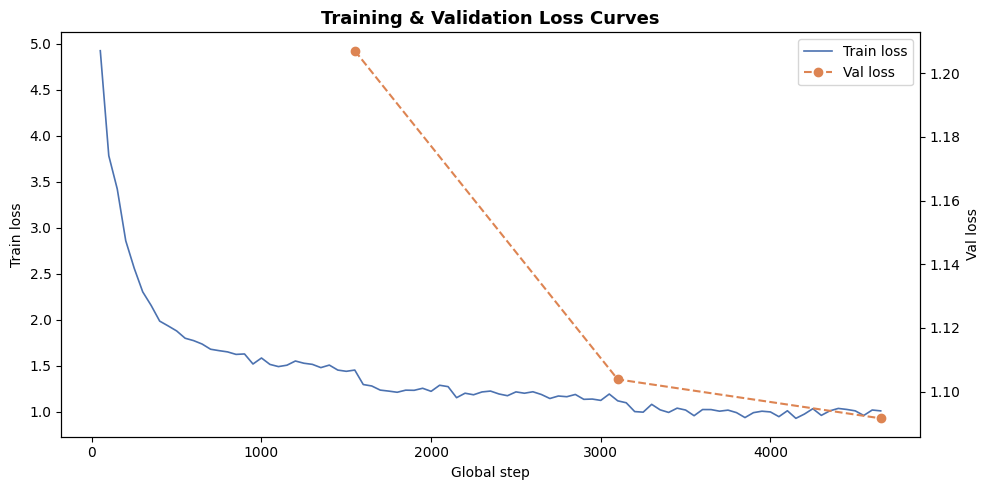

Loss curves saved → loss_curves.png


In [ ]:


training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    learning_rate               = LEARNING_RATE,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    gradient_accumulation_steps = GRAD_ACCUM_STEPS,
    num_train_epochs            = NUM_EPOCHS,
    weight_decay                = WEIGHT_DECAY,
    load_best_model_at_end      = True,
    metric_for_best_model       = "eval_loss",
    seed                        = SEED,
    logging_steps               = 50,
    report_to                   = "none",
    fp16=True
)

trainer = Trainer(
    model         = model,
    args          = training_args,
    train_dataset = train_dataset,
    eval_dataset  = val_dataset,
    data_collator = default_data_collator,
)

print("Starting training...")
train_start  = time.time()
train_output = trainer.train()
train_end    = time.time()
wall_clock_hrs = (train_end - train_start) / 3600
print(f"✅ Training complete — wall-clock time: {wall_clock_hrs:.2f} hours")

# ── Loss Curves ────────────────────────────────────────────────────────────────
log_history = trainer.state.log_history

train_steps  = [e["step"]      for e in log_history if "loss"      in e]
train_losses = [e["loss"]      for e in log_history if "loss"      in e]
eval_epochs  = [e["epoch"]     for e in log_history if "eval_loss" in e]
eval_losses  = [e["eval_loss"] for e in log_history if "eval_loss" in e]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_steps, train_losses, label="Train loss", color="#4C72B0", linewidth=1.2)
ax2 = ax.twinx()
total_train_steps  = train_steps[-1] if train_steps else 1
eval_steps_approx  = [int(e / NUM_EPOCHS * total_train_steps) for e in eval_epochs]
ax2.plot(eval_steps_approx, eval_losses, "o--", label="Val loss", color="#DD8452", linewidth=1.5)

ax.set_xlabel("Global step")
ax.set_ylabel("Train loss")
ax2.set_ylabel("Val loss")
ax.set_title("Training & Validation Loss Curves", fontsize=13, fontweight="bold")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("Loss curves saved → loss_curves.png")

In [ ]:
SAVE_PATH = "./distilbert-squad-final"
model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f"Model and tokenizer saved → {SAVE_PATH}")

Model and tokenizer saved → ./distilbert-squad-final


In [ ]:
from transformers import AutoTokenizer, AutoModelForQuestionAnswering
import torch

SAVE_PATH = "./distilbert-squad-final"
model = AutoModelForQuestionAnswering.from_pretrained(SAVE_PATH)
tokenizer = AutoTokenizer.from_pretrained(SAVE_PATH)
model.eval()

def qa_predict(question, context):
    inputs = tokenizer(question, context, return_tensors="pt", truncation=True, max_length=384)
    with torch.no_grad():
        outputs = model(**inputs)
    start = outputs.start_logits.argmax().item()
    end = outputs.end_logits.argmax().item() + 1
    return tokenizer.decode(inputs["input_ids"][0][start:end], skip_special_tokens=True)

demos = [
    {"question": "Who introduced BERT?", "context": "BERT was introduced by Devlin et al. from Google AI Language in 2019."},
    {"question": "How many parameters does DistilBERT have?", "context": "DistilBERT reduces BERT's parameter count by 40%, resulting in approximately 66 million parameters."},
    {"question": "What dataset was used for evaluation?", "context": "The model was evaluated on SQuAD v1.1, which contains over 107,000 question-answer pairs."},
]

for d in demos:
    answer = qa_predict(d["question"], d["context"])
    print(f"Q: {d['question']}")
    print(f"A: {answer}")
    print()

Q: Who introduced BERT?
A: devlin

Q: How many parameters does DistilBERT have?
A: 66 million

Q: What dataset was used for evaluation?
A: squad v1. 1



In [ ]:
import time
import torch

# 1. تحديد الجهاز كـ CPU
device_cpu = torch.device("cpu")

# نقل الموديل للـ CPU
model.to(device_cpu)
model.eval()

# 2. تجهيز سؤال ونص تجريبي

sample_para = val_articles[0]["paragraphs"][0]
sample_qa   = sample_para["qas"][0]
question    = sample_qa["question"]
context     = sample_para["context"]

# 3. Tokenization
inputs = tokenizer(
    question,
    context,
    max_length=384,
    truncation="only_second",
    return_tensors="pt"
)

# نقل الـ tensors للـ CPU
inputs = {k: v.to(device_cpu) for k, v in inputs.items()}

# 4. قياس زمن الـ inference
start_time = time.time()

with torch.no_grad():
    outputs = model(**inputs)

end_time = time.time()

cpu_latency = (end_time - start_time) * 1000

print(f"✅ Question: {question}")
print(f"🚀 Inference time on CPU: {cpu_latency:.2f} ms")

# لو هتكمل تدريب/تجارب على GPU
# model.to("cuda")

✅ Question: Who founded Philadelphia?
🚀 Inference time on CPU: 33.38 ms


### 🔷 <font color="#9CE2FF">Salma's Work start</font>

# The evaluation and error analysis

This section is my part of the project. I evaluate the baseline and the fine-tuned DistilBERT model using the official SQuAD-style metrics, then I compare the results and inspect some wrong predictions. The goal is not only to report numbers, but also to understand what kinds of mistakes the model still makes.


## Evaluation Setup

For evaluation, I use Exact Match and F1 score. Exact Match checks if the predicted answer is exactly the same as a correct answer after normalization. F1 is more flexible because it gives partial credit when the predicted answer shares words with the correct answer.

I use the same scoring function for both the BM25 baseline and DistilBERT so the comparison is fair.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import torch
from transformers import pipeline

# I use a smaller number first so evaluation does not take too long.
EVAL_LIMIT = 500


def get_validation_examples(articles, limit=None):
    examples = []

    for article in articles:
        title = article.get("title", "")

        for para in article["paragraphs"]:
            context = para["context"]

            for qa in para["qas"]:
                # Some datasets may contain unanswerable questions, so I skip them here.
                if len(qa["answers"]) == 0:
                    continue

                examples.append({
                    "id": qa["id"],
                    "title": title,
                    "question": qa["question"],
                    "context": context,
                    "gold_answers": [a["text"] for a in qa["answers"]]
                })

                if limit is not None and len(examples) >= limit:
                    return examples

    return examples


def score_prediction(gold_answers, prediction):
    # SQuAD gives the prediction the best score over all available gold answers.
    em = max(exact_match_score(gold, prediction) for gold in gold_answers)
    f1 = max(f1_score(gold, prediction) for gold in gold_answers)
    return em, f1


val_examples = get_validation_examples(val_articles, limit=EVAL_LIMIT)

print(f"Validation examples used: {len(val_examples)}")


Validation examples used: 500


## Baseline Evaluation

First, I evaluate the BM25 baseline. This baseline chooses a sentence from the context based on word overlap with the question. It is much simpler than DistilBERT, but it gives us a useful starting point for comparison.


In [ ]:
baseline_rows = []

for ex in val_examples:
    prediction = baseline_predictions.get(ex["id"], "")
    em, f1 = score_prediction(ex["gold_answers"], prediction)

    baseline_rows.append({
        "id": ex["id"],
        "title": ex["title"],
        "question": ex["question"],
        "gold_answers": " | ".join(ex["gold_answers"]),
        "prediction": prediction,
        "em": em,
        "f1": f1
    })

baseline_df = pd.DataFrame(baseline_rows)

baseline_em = baseline_df["em"].mean() * 100
baseline_f1 = baseline_df["f1"].mean() * 100

print("BM25 Baseline Results")
print(f"Exact Match: {baseline_em:.2f}%")
print(f"F1 Score   : {baseline_f1:.2f}%")

baseline_df.to_csv("baseline_results.csv", index=False)
baseline_df.head()


BM25 Baseline Results
Exact Match: 0.00%
F1 Score   : 12.75%


,id,title,question,gold_answers,prediction,em,f1
0,572a8d2834ae481900deab79,Philadelphia,Who founded Philadelphia?,William Penn,"In 1682, William Penn founded the city to serv...",False,0.266667
1,572a8d2834ae481900deab7a,Philadelphia,What role did Philadelphia play in the America...,a meeting place for the Founding Fathers,Philadelphia played an instrumental role in th...,False,0.312500
2,572a8d2834ae481900deab7b,Philadelphia,What purpose did Philadelphia serve while D.C....,temporary U.S. capital,"capital while Washington, D.C., was under cons...",False,0.200000
3,572a8d2834ae481900deab7c,Philadelphia,When did it reach 2 million occupants>,1950,It became a prime destination for African-Amer...,False,0.117647
4,572a8e0834ae481900deab81,Philadelphia,What was the historical economic base of Phila...,manufacturing,The economic impact of these changes would red...,False,0.000000


## DistilBERT Evaluation

Next, I evaluate the fine-tuned DistilBERT model. For each validation example, the model receives the question and context, then returns the answer span it thinks is most likely. I save the prediction, confidence score, Exact Match, and F1 score so these results can be used later in the report.


In [ ]:
device = 0 if torch.cuda.is_available() else -1

qa_pipeline = pipeline(
    "question-answering",
    model=SAVE_PATH,
    tokenizer=SAVE_PATH,
    device=device
)

model_rows = []
start_time = time.time()

for i, ex in enumerate(val_examples):
    output = qa_pipeline(
        question=ex["question"],
        context=ex["context"],
        max_answer_len=40
    )

    prediction = output["answer"]
    em, f1 = score_prediction(ex["gold_answers"], prediction)

    model_rows.append({
        "id": ex["id"],
        "title": ex["title"],
        "question": ex["question"],
        "gold_answers": " | ".join(ex["gold_answers"]),
        "prediction": prediction,
        "confidence": output["score"],
        "em": em,
        "f1": f1
    })

    # This progress message helps while the cell is running.
    if (i + 1) % 50 == 0:
        print(f"Evaluated {i + 1}/{len(val_examples)} examples")

total_time = time.time() - start_time

model_df = pd.DataFrame(model_rows)

model_em = model_df["em"].mean() * 100
model_f1 = model_df["f1"].mean() * 100
avg_latency = total_time / len(val_examples)

print("DistilBERT Results")
print(f"Exact Match       : {model_em:.2f}%")
print(f"F1 Score          : {model_f1:.2f}%")
print(f"Average latency   : {avg_latency:.4f} seconds/example")

model_df.to_csv("distilbert_results.csv", index=False)
model_df.head()


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Evaluated 50/500 examples
Evaluated 100/500 examples
Evaluated 150/500 examples
Evaluated 200/500 examples
Evaluated 250/500 examples
Evaluated 300/500 examples
Evaluated 350/500 examples
Evaluated 400/500 examples
Evaluated 450/500 examples
Evaluated 500/500 examples
DistilBERT Results
Exact Match       : 66.60%
F1 Score          : 77.89%
Average latency   : 0.0054 seconds/example


,id,title,question,gold_answers,prediction,confidence,em,f1
0,572a8d2834ae481900deab79,Philadelphia,Who founded Philadelphia?,William Penn,William Penn,0.994119,True,1.000000
1,572a8d2834ae481900deab7a,Philadelphia,What role did Philadelphia play in the America...,a meeting place for the Founding Fathers,meeting place for the Founding Fathers of the ...,0.068017,False,0.769231
2,572a8d2834ae481900deab7b,Philadelphia,What purpose did Philadelphia serve while D.C....,temporary U.S. capital,temporary U.S. capital,0.765984,True,1.000000
3,572a8d2834ae481900deab7c,Philadelphia,When did it reach 2 million occupants>,1950,1950,0.965493,True,1.000000
4,572a8e0834ae481900deab81,Philadelphia,What was the historical economic base of Phila...,manufacturing,manufacturing,0.978877,True,1.000000


## Comparison Between Baseline and DistilBERT

After evaluating both methods, I compare their Exact Match and F1 scores. This shows whether the fine-tuned transformer model improves over the simple BM25 baseline.


In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["BM25 Baseline", "DistilBERT"],
    "Exact Match": [baseline_em, model_em],
    "F1 Score": [baseline_f1, model_f1]
})

comparison_df.to_csv("comparison_table.csv", index=False)
comparison_df


,Model,Exact Match,F1 Score
0,BM25 Baseline,0.0,12.747165
1,DistilBERT,66.6,77.893306


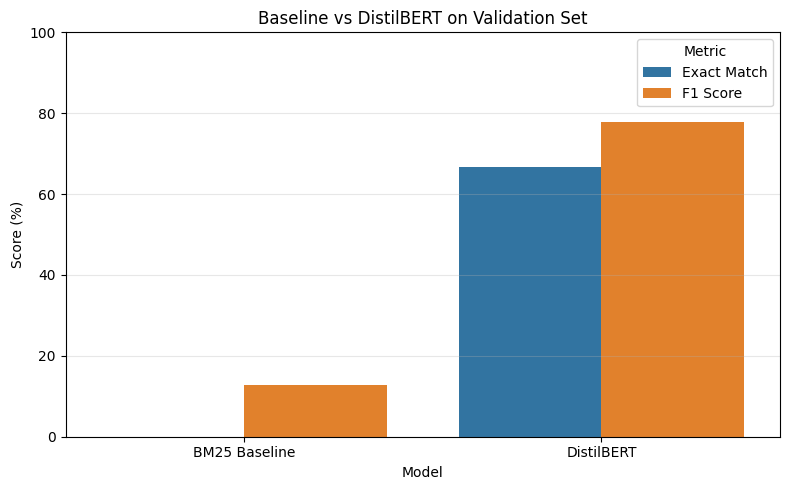

In [ ]:
plot_df = comparison_df.melt(
    id_vars="Model",
    value_vars=["Exact Match", "F1 Score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric")

plt.title("Baseline vs DistilBERT on Validation Set")
plt.ylabel("Score (%)")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("em_f1_comparison.png", dpi=150)
plt.show()


## Error Analysis

The scores give a general view of performance, but they do not show why the model fails. For this reason, I inspect a small set of wrong predictions. I start with examples where Exact Match is zero, then look at whether the answer is partially correct, too long, related but incorrect, or completely wrong.


In [ ]:
wrong_examples = model_df[model_df["em"] == 0].copy()

# Sorting by F1 puts the weakest predictions first.
wrong_examples = wrong_examples.sort_values("f1").head(15)

wrong_examples[[
    "question",
    "gold_answers",
    "prediction",
    "em",
    "f1"
]].to_csv("wrong_examples.csv", index=False)

wrong_examples[[
    "question",
    "gold_answers",
    "prediction",
    "em",
    "f1"
]]


,question,gold_answers,prediction,em,f1
180,What was it in 2014?,65%,the scores dropped significantly to 45.2% on m...,False,0.0
239,What is the name of the English language's ear...,Old English,Anglo-Saxon,False,0.0
235,What city in Israel is a sister city to Philad...,Tel Aviv,"Toruń, Poland",False,0.0
232,When was the 610 area code added?,1994,1999,False,0.0
334,What letter from the Latin alphabet replaces t...,g,⟨g⟩,False,0.0
192,Where was the first radio license granted?,St. Joseph's College,Philadelphia,False,0.0
181,Is that the above or below the national average?,below the national and state averages,65%,False,0.0
346,Conquests by who began the transformation of t...,Murad I,Mehmed the Conqueror,False,0.0
173,Has violent crime rate fallen or risen in the ...,fell,declined significantly,False,0.0
162,How many congressional districts are there in ...,four,six,False,0.0


## Suggested Error Categories

The next cell gives simple suggested categories for the wrong examples. These labels are not meant to be perfect. I use them as a first pass, then manually inspect the examples and adjust the final explanation in the report if needed.


In [ ]:
def categorize_error(row):
    gold = row["gold_answers"].lower()
    pred = row["prediction"].lower()

    if pred.strip() == "":
        return "empty prediction"

    if row["f1"] > 0.6:
        return "partially correct span"

    if len(pred.split()) > 15:
        return "answer too long"

    if any(token in pred for token in gold.split()):
        return "related but wrong span"

    return "wrong answer"


wrong_examples["suggested_error_type"] = wrong_examples.apply(categorize_error, axis=1)

# These are rule-based suggestions only.
# I will inspect the examples manually when writing the report.
error_summary = wrong_examples["suggested_error_type"].value_counts().reset_index()
error_summary.columns = ["Suggested Error Type", "Count"]

wrong_examples.to_csv("wrong_examples_with_categories.csv", index=False)
error_summary.to_csv("error_summary.csv", index=False)

error_summary

,Suggested Error Type,Count
0,wrong answer,14
1,related but wrong span,1


In [ ]:
wrong_examples[[
    "question",
    "gold_answers",
    "prediction",
    "f1",
    "suggested_error_type"
]]

,question,gold_answers,prediction,f1,suggested_error_type
180,What was it in 2014?,65%,the scores dropped significantly to 45.2% on m...,0.0,wrong answer
239,What is the name of the English language's ear...,Old English,Anglo-Saxon,0.0,wrong answer
235,What city in Israel is a sister city to Philad...,Tel Aviv,"Toruń, Poland",0.0,wrong answer
232,When was the 610 area code added?,1994,1999,0.0,wrong answer
334,What letter from the Latin alphabet replaces t...,g,⟨g⟩,0.0,related but wrong span
192,Where was the first radio license granted?,St. Joseph's College,Philadelphia,0.0,wrong answer
181,Is that the above or below the national average?,below the national and state averages,65%,0.0,wrong answer
346,Conquests by who began the transformation of t...,Murad I,Mehmed the Conqueror,0.0,wrong answer
173,Has violent crime rate fallen or risen in the ...,fell,declined significantly,0.0,wrong answer
162,How many congressional districts are there in ...,four,six,0.0,wrong answer


## Small Robustness Check With Reworded Questions

The project also asks about robustness. As a small first check, I test the model on a few reworded questions. The context and correct answer stay the same, but the question wording changes. If the score drops after rewording, this suggests the model is sensitive to question phrasing.



In [ ]:
robustness_examples = []

manual_paraphrases = [
    "Which person founded Philadelphia?",
    "How was Philadelphia important during the American Revolution?",
    "What function did Philadelphia have before Washington, D.C. was completed?",
    "In what year did the population reach 2 million?",
    "What was Philadelphia's economy mainly based on historically?",
    "When did the city come close to bankruptcy?",
    "Where did rich residents move?",
    "Who took the place of the wealthy residents?",
    "What is the city's GDP?",
    "How does it rank compared with other cities in the United States?"
]

for ex, paraphrased_q in zip(val_examples[:10], manual_paraphrases):
    robustness_examples.append({
        **ex,
        "original_question": ex["question"],
        "paraphrased_question": paraphrased_q
    })

robustness_df = pd.DataFrame(robustness_examples)
robustness_df[["original_question", "paraphrased_question", "gold_answers"]]

,original_question,paraphrased_question,gold_answers
0,Who founded Philadelphia?,Which person founded Philadelphia?,[William Penn]
1,What role did Philadelphia play in the America...,How was Philadelphia important during the Amer...,[a meeting place for the Founding Fathers]
2,What purpose did Philadelphia serve while D.C....,What function did Philadelphia have before Was...,[temporary U.S. capital]
3,When did it reach 2 million occupants>,In what year did the population reach 2 million?,[1950]
4,What was the historical economic base of Phila...,What was Philadelphia's economy mainly based o...,[manufacturing]
5,When did the city near bankruptcy?,When did the city come close to bankruptcy?,[late 1980s]
6,Where did wealthy residents move?,Where did rich residents move?,[suburbs]
7,Who replaced the wealthy?,Who took the place of the wealthy residents?,[immigrants]
8,What is the GDP of the city?,What is the city's GDP?,[$388 billion]
9,Where does it rank in comparison to other US c...,How does it rank compared with other cities in...,[fourth]


In [ ]:
robustness_rows = []

for ex in robustness_examples:
    original_output = qa_pipeline(
        question=ex["original_question"],
        context=ex["context"],
        max_answer_len=40
    )
    para_output = qa_pipeline(
        question=ex["paraphrased_question"],
        context=ex["context"],
        max_answer_len=40
    )

    original_em, original_f1 = score_prediction(ex["gold_answers"], original_output["answer"])
    para_em, para_f1 = score_prediction(ex["gold_answers"], para_output["answer"])

    robustness_rows.append({
        "id": ex["id"],
        "original_question": ex["original_question"],
        "paraphrased_question": ex["paraphrased_question"],
        "gold_answers": " | ".join(ex["gold_answers"]),
        "original_prediction": original_output["answer"],
        "paraphrased_prediction": para_output["answer"],
        "original_em": original_em,
        "paraphrased_em": para_em,
        "original_f1": original_f1,
        "paraphrased_f1": para_f1
    })

robustness_results_df = pd.DataFrame(robustness_rows)
robustness_results_df.to_csv("robustness_results.csv", index=False)

print("Original questions")
print(f"Exact Match: {robustness_results_df['original_em'].mean() * 100:.2f}%")
print(f"F1 Score   : {robustness_results_df['original_f1'].mean() * 100:.2f}%")

print("Paraphrased questions")
print(f"Exact Match: {robustness_results_df['paraphrased_em'].mean() * 100:.2f}%")
print(f"F1 Score   : {robustness_results_df['paraphrased_f1'].mean() * 100:.2f}%")

robustness_results_df


Original questions
Exact Match: 70.00%
F1 Score   : 79.69%
Paraphrased questions
Exact Match: 70.00%
F1 Score   : 77.71%


,id,original_question,paraphrased_question,gold_answers,original_prediction,paraphrased_prediction,original_em,paraphrased_em,original_f1,paraphrased_f1
0,572a8d2834ae481900deab79,Who founded Philadelphia?,Which person founded Philadelphia?,William Penn,William Penn,William Penn,True,True,1.000000,1.000000
1,572a8d2834ae481900deab7a,What role did Philadelphia play in the America...,How was Philadelphia important during the Amer...,a meeting place for the Founding Fathers,meeting place for the Founding Fathers of the ...,a meeting place,False,False,0.769231,0.571429
2,572a8d2834ae481900deab7b,What purpose did Philadelphia serve while D.C....,What function did Philadelphia have before Was...,temporary U.S. capital,temporary U.S. capital,temporary U.S. capital,True,True,1.000000,1.000000
3,572a8d2834ae481900deab7c,When did it reach 2 million occupants>,In what year did the population reach 2 million?,1950,1950,1950,True,True,1.000000,1.000000
4,572a8e0834ae481900deab81,What was the historical economic base of Phila...,What was Philadelphia's economy mainly based o...,manufacturing,manufacturing,manufacturing,True,True,1.000000,1.000000
5,572a8e0834ae481900deab82,When did the city near bankruptcy?,When did the city come close to bankruptcy?,late 1980s,late 1980s,late 1980s,True,True,1.000000,1.000000
6,572a8e0834ae481900deab83,Where did wealthy residents move?,Where did rich residents move?,suburbs,suburbs,suburbs,True,True,1.000000,1.000000
7,572a8e0834ae481900deab84,Who replaced the wealthy?,Who took the place of the wealthy residents?,immigrants,wealthier residents moved into the nearby subu...,wealthier residents moved into the nearby subu...,False,False,0.200000,0.200000
8,572a8ebc34ae481900deab89,What is the GDP of the city?,What is the city's GDP?,$388 billion,$388 billion,$388 billion,True,True,1.000000,1.000000
9,572a8ebc34ae481900deab8a,Where does it rank in comparison to other US c...,How does it rank compared with other cities in...,fourth,ninth,ninth,False,False,0.000000,0.000000


### 🔷 <font color="#9CE2FF">Salma's Work Ends</font>

# fine tunning tinybert wit sam config

# toknize

In [ ]:
# ══════════════════════════════════════════════════════
# Student D — TinyBERT Fine-Tuning (same config as DistilBERT)
# ══════════════════════════════════════════════════════

import os, time, warnings, random
import numpy as np
import torch
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForQuestionAnswering,
    TrainingArguments,
    Trainer,
    default_data_collator,
    pipeline,
)

warnings.filterwarnings("ignore")

# ── Reproducibility ─────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ── Hyperparameters (same as DistilBERT) ────────────────────
TINYBERT_CHECKPOINT  = "huawei-noah/TinyBERT_General_4L_312D"
MAX_SEQ_LENGTH       = 384
STRIDE               = 128
BATCH_SIZE           = 8
GRAD_ACCUM_STEPS     = 4
NUM_EPOCHS           = 20
LEARNING_RATE        = 1e-5
WEIGHT_DECAY         = 0.01
WARMUP_RATIO         = 0.1       # أول 10%
TINYBERT_OUTPUT_DIR  = "./tinybert-squad-output"
TINYBERT_SAVE_PATH   = "./tinybert-squad-final"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print("TinyBERT configuration loaded ✅")

Using device: cuda
TinyBERT configuration loaded ✅


In [ ]:
# TinyBERT uses BERT tokenizer (not DistilBERT's)
# We re-tokenize using TinyBERT's own tokenizer

tinybert_tokenizer = AutoTokenizer.from_pretrained(TINYBERT_CHECKPOINT)

def tokenize_tinybert(question, context):
    return tinybert_tokenizer(
        question,
        context,
        truncation="only_second",
        max_length=MAX_SEQ_LENGTH,
        stride=STRIDE,
        return_overflowing_tokens=True,
        padding="max_length",
        return_offsets_mapping=True,
        return_tensors="pt"
    )

def offset_mapping_tinybert(answer, encoding_strided):
    ans_start = answer["answer_start"]
    ans_end   = ans_start + len(answer["text"])
    results   = []

    for i in range(encoding_strided["input_ids"].shape[0]):
        offsets      = encoding_strided["offset_mapping"][i].tolist()
        sequence_ids = encoding_strided.sequence_ids(i)

        ctx_start = next(j for j, s in enumerate(sequence_ids) if s == 1)
        ctx_end   = len(sequence_ids) - 1 - next(
            j for j, s in enumerate(reversed(sequence_ids)) if s == 1
        )

        if offsets[ctx_start][0] > ans_start or offsets[ctx_end][1] < ans_end:
            start_pos, end_pos = 0, 0
        else:
            start_pos = next(
                (j for j in range(ctx_start, ctx_end + 1)
                 if offsets[j][0] <= ans_start < offsets[j][1]), ctx_start
            )
            end_pos = next(
                (j for j in range(ctx_end, ctx_start - 1, -1)
                 if offsets[j][1] >= ans_end > offsets[j][0]), ctx_end
            )

        results.append((start_pos, end_pos))

    return results

print("TinyBERT tokenizer loaded ✅")

config.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

TinyBERT tokenizer loaded ✅


In [ ]:
tb_train_input_ids, tb_train_masks, tb_train_starts, tb_train_ends = [], [], [], []
tb_val_input_ids,   tb_val_masks,   tb_val_starts,   tb_val_ends   = [], [], [], []

print("Processing train split...")
for article in train_articles:
    for para in article["paragraphs"]:
        for qa in para["qas"]:
            enc = tokenize_tinybert(qa["question"], para["context"])
            chunks = offset_mapping_tinybert(qa["answers"][0], enc)
            for i, (s, e) in enumerate(chunks):
                tb_train_input_ids.append(enc["input_ids"][i].tolist())
                tb_train_masks.append(enc["attention_mask"][i].tolist())
                tb_train_starts.append(s)
                tb_train_ends.append(e)

print("Processing validation split...")
for article in val_articles:
    for para in article["paragraphs"]:
        for qa in para["qas"]:
            enc = tokenize_tinybert(qa["question"], para["context"])
            chunks = offset_mapping_tinybert(qa["answers"][0], enc)
            for i, (s, e) in enumerate(chunks):
                tb_val_input_ids.append(enc["input_ids"][i].tolist())
                tb_val_masks.append(enc["attention_mask"][i].tolist())
                tb_val_starts.append(s)
                tb_val_ends.append(e)

tb_train_dataset = Dataset.from_dict({
    "input_ids":       tb_train_input_ids,
    "attention_mask":  tb_train_masks,
    "start_positions": tb_train_starts,
    "end_positions":   tb_train_ends,
})
tb_val_dataset = Dataset.from_dict({
    "input_ids":       tb_val_input_ids,
    "attention_mask":  tb_val_masks,
    "start_positions": tb_val_starts,
    "end_positions":   tb_val_ends,
})
tb_train_dataset.set_format("torch")
tb_val_dataset.set_format("torch")

print(f"TinyBERT Train chunks : {len(tb_train_dataset):,}")
print(f"TinyBERT Val chunks   : {len(tb_val_dataset):,}")

Processing train split...
Processing validation split...
TinyBERT Train chunks : 50,527
TinyBERT Val chunks   : 9,398


# Model Architecture


In [ ]:
tinybert_model = AutoModelForQuestionAnswering.from_pretrained(TINYBERT_CHECKPOINT).to(DEVICE)

total_params     = sum(p.numel() for p in tinybert_model.parameters())
trainable_params = sum(p.numel() for p in tinybert_model.parameters() if p.requires_grad)

print(f"Model          : {TINYBERT_CHECKPOINT}")
print(f"Total params   : {total_params/1e6:.1f}M")
print(f"Trainable      : {trainable_params/1e6:.1f}M")
print(f"Layers         : 4 Transformer encoder layers")
print(f"Hidden size    : 312  |  Heads: 12  |  FFN: 1200")
print()
print(tinybert_model)

pytorch_model.bin:   0%|          | 0.00/62.7M [00:00<?, ?B/s]

Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at huawei-noah/TinyBERT_General_4L_312D and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model          : huawei-noah/TinyBERT_General_4L_312D
Total params   : 14.3M
Trainable      : 14.3M
Layers         : 4 Transformer encoder layers
Hidden size    : 312  |  Heads: 12  |  FFN: 1200

BertForQuestionAnswering(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 312, padding_idx=0)
      (position_embeddings): Embedding(512, 312)
      (token_type_embeddings): Embedding(2, 312)
      (LayerNorm): LayerNorm((312,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-3): 4 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=312, out_features=312, bias=True)
              (key): Linear(in_features=312, out_features=312, bias=True)
              (value): Linear(in_features=312, out_features=312, bias=True)
              (dropout): Dropout(p=0.1, inpla

# Training

Starting TinyBERT training...


Epoch,Training Loss,Validation Loss
1,4.159000,4.022113
2,3.107700,2.768477
3,2.846800,2.430095
4,2.433900,2.172405
5,2.219600,1.983870
6,2.053700,1.871251
7,1.952000,1.840622
8,1.866800,1.791692
9,1.823800,1.768142
10,1.788800,1.768656


✅ TinyBERT training complete — wall-clock time: 1.43 hours


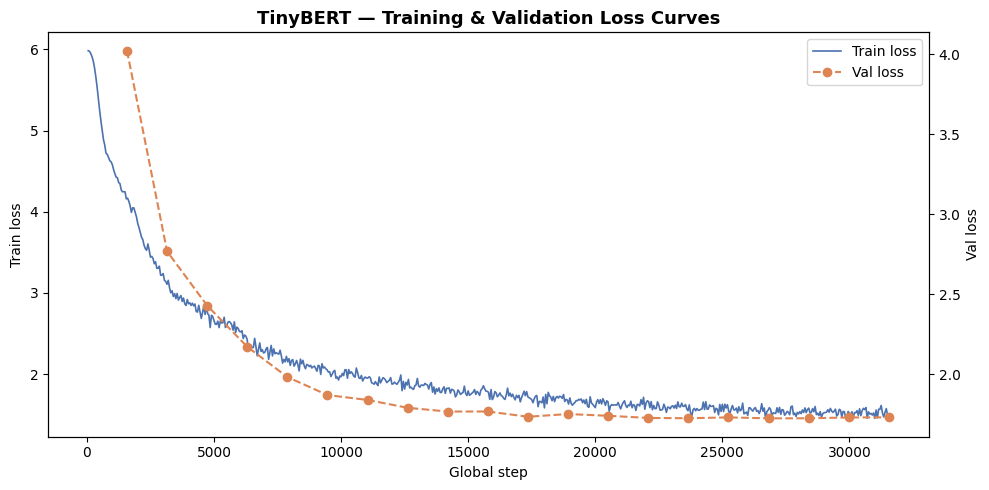

Loss curves saved → tinybert_loss_curves.png


In [ ]:
tinybert_training_args = TrainingArguments(
    output_dir                  = TINYBERT_OUTPUT_DIR,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    learning_rate               = LEARNING_RATE,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    gradient_accumulation_steps = GRAD_ACCUM_STEPS,
    num_train_epochs            = NUM_EPOCHS,
    weight_decay                = WEIGHT_DECAY,
    load_best_model_at_end      = True,
    warmup_ratio                = WARMUP_RATIO,
    metric_for_best_model       = "eval_loss",
    seed                        = SEED,
    logging_steps               = 50,
    report_to                   = "none",
    fp16                        = True,
)

tinybert_trainer = Trainer(
    model         = tinybert_model,
    args          = tinybert_training_args,
    train_dataset = tb_train_dataset,
    eval_dataset  = tb_val_dataset,
    data_collator = default_data_collator,
)

print("Starting TinyBERT training...")
train_start  = time.time()
train_output = tinybert_trainer.train()
train_end    = time.time()

wall_clock_hrs = (train_end - train_start) / 3600
print(f"✅ TinyBERT training complete — wall-clock time: {wall_clock_hrs:.2f} hours")

# ── Loss Curves ──────────────────────────────────────────────
log_history  = tinybert_trainer.state.log_history
train_steps  = [e["step"]      for e in log_history if "loss"      in e]
train_losses = [e["loss"]      for e in log_history if "loss"      in e]
eval_epochs  = [e["epoch"]     for e in log_history if "eval_loss" in e]
eval_losses  = [e["eval_loss"] for e in log_history if "eval_loss" in e]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_steps, train_losses, label="Train loss", color="#4C72B0", linewidth=1.2)
ax2 = ax.twinx()
total_train_steps = train_steps[-1] if train_steps else 1
eval_steps_approx = [int(e / NUM_EPOCHS * total_train_steps) for e in eval_epochs]
ax2.plot(eval_steps_approx, eval_losses, "o--", label="Val loss", color="#DD8452", linewidth=1.5)

ax.set_xlabel("Global step")
ax.set_ylabel("Train loss")
ax2.set_ylabel("Val loss")
ax.set_title("TinyBERT — Training & Validation Loss Curves", fontsize=13, fontweight="bold")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
plt.savefig("tinybert_loss_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("Loss curves saved → tinybert_loss_curves.png")

# save model

In [ ]:
tinybert_model.save_pretrained(TINYBERT_SAVE_PATH)
tinybert_tokenizer.save_pretrained(TINYBERT_SAVE_PATH)
print(f"TinyBERT model and tokenizer saved → {TINYBERT_SAVE_PATH}")

TinyBERT model and tokenizer saved → ./tinybert-squad-final


# Inference Demo


In [ ]:
tb_qa_pipeline = pipeline(
    "question-answering",
    model=tinybert_model,
    tokenizer=tinybert_tokenizer,
    device=-1
)

demos = [
    {
        "question": "Who introduced BERT?",
        "context": "BERT was introduced by Devlin et al. from Google AI Language in 2019. It achieved state-of-the-art results on eleven NLP tasks."
    },
    {
        "question": "How many parameters does DistilBERT have?",
        "context": "DistilBERT, proposed by Sanh et al., reduces BERT's parameter count by 40%, resulting in approximately 66 million parameters while retaining 97% of BERT's language understanding capability."
    },
    {
        "question": "What dataset was used for evaluation?",
        "context": "The model was evaluated on SQuAD v1.1, which contains over 107,000 question-answer pairs from 536 Wikipedia articles."
    }
]

print("── TinyBERT Inference Demo ──────────────────────────────────")
for d in demos:
    ans = tb_qa_pipeline(question=d["question"], context=d["context"])
    print(f"Q: {d['question']}")
    print(f"A: {ans['answer']}  (score: {ans['score']:.4f})")
    print()

── TinyBERT Inference Demo ──────────────────────────────────
Q: Who introduced BERT?
A: Google  (score: 0.4979)

Q: How many parameters does DistilBERT have?
A: 66 million  (score: 0.1895)

Q: What dataset was used for evaluation?
A: v1  (score: 0.1092)



# CPU Latency

In [ ]:
device_cpu = torch.device("cpu")
tinybert_model.to(device_cpu)
tinybert_model.eval()

sample_para = val_articles[5]["paragraphs"][0]
sample_qa   = sample_para["qas"][0]
question    = sample_qa["question"]
context     = sample_para["context"]

inputs = tinybert_tokenizer(
    question, context,
    max_length=384,
    truncation="only_second",
    return_tensors="pt"
)
inputs = {k: v.to(device_cpu) for k, v in inputs.items()}

start_time = time.time()
with torch.no_grad():
    outputs = tinybert_model(**inputs)
end_time = time.time()

tinybert_cpu_latency = (end_time - start_time) * 1000

# ── استخراج الجواب ──────────────────────────────────
start_logits = outputs.start_logits[0]
end_logits   = outputs.end_logits[0]

answer_start = start_logits.argmax().item()
answer_end   = (end_logits[answer_start:].argmax() + answer_start).item() + 1

answer_tokens = inputs["input_ids"][0][answer_start:answer_end]
answer        = tinybert_tokenizer.decode(answer_tokens.tolist(), skip_special_tokens=True)

print(f"✅ Question : {question}")
print(f"💡 Answer   : {answer}")
print(f"🚀 TinyBERT Inference time on CPU: {tinybert_cpu_latency:.2f} ms")

✅ Question : Where did Hokkien originate?
💡 Answer   : southern fujian
🚀 TinyBERT Inference time on CPU: 10.02 ms


In [ ]:
device_cpu = torch.device("cpu")
tinybert_model.to(device_cpu)
tinybert_model.eval()

demos = [
    {
        "question": "Who introduced BERT?",
        "context": "BERT was introduced by Devlin et al. from Google AI Language in 2019. It achieved state-of-the-art results on eleven NLP tasks."
    },
    {
        "question": "How many parameters does DistilBERT have?",
        "context": "DistilBERT, proposed by Sanh et al., reduces BERT's parameter count by 40%, resulting in approximately 66 million parameters while retaining 97% of BERT's language understanding capability."
    },
    {
        "question": "What dataset was used for evaluation?",
        "context": "The model was evaluated on SQuAD v1.1, which contains over 107,000 question-answer pairs from 536 Wikipedia articles."
    }
]

print("── TinyBERT Inference Demo ──────────────────────────────────────")
for d in demos:
    inputs = tinybert_tokenizer(
        d["question"], d["context"],
        max_length=384,
        truncation="only_second",
        return_tensors="pt"
    )
    inputs = {k: v.to(device_cpu) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = tinybert_model(**inputs)

    answer_start  = outputs.start_logits.argmax(dim=-1).item()
    answer_end    = outputs.end_logits.argmax(dim=-1).item() + 1
    answer_tokens = inputs["input_ids"][0][answer_start:answer_end]
    answer        = tinybert_tokenizer.decode(answer_tokens.tolist(), skip_special_tokens=True)

    print(f"Q: {d['question']}")
    print(f"A: {answer}")
    print()

── TinyBERT Inference Demo ──────────────────────────────────────
Q: Who introduced BERT?
A: google

Q: How many parameters does DistilBERT have?
A: 66 million

Q: What dataset was used for evaluation?
A: v1



### 🔷 <font color="#9CE2FF">Salma's Work start</font>

### 🔷 <font color="8dE2FF">TinyBERT Ablations</font>

<div style="width:260px; text-align:center; font-family:Arial;">

<div style="background:#E3F2FD; border:2px solid #1565C0; padding:10px; border-radius:10px;">
TinyBERT has:
</div>
<br>

<div style="background:#FFF3E0; border:2px solid #EF6C00; padding:10px; border-radius:10px;">
Embeddings
</div>
⬇️

<div style="background:#E8F5E9; border:2px solid #2E7D32; padding:10px; border-radius:10px;">
Encoder Layer 0
</div>
⬇️

<div style="background:#E8F5E9; border:2px solid #2E7D32; padding:10px; border-radius:10px;">
Encoder Layer 1
</div>
⬇️

<div style="background:#E8F5E9; border:2px solid #2E7D32; padding:10px; border-radius:10px;">
Encoder Layer 2
</div>
⬇️

<div style="background:#E8F5E9; border:2px solid #2E7D32; padding:10px; border-radius:10px;">
Encoder Layer 3
</div>
⬇️

<div style="background:#FCE4EC; border:2px solid #AD1457; padding:10px; border-radius:10px;">
QA Head
</div>


</div>

## Upcoming Ablation Plan

For the next phase, I will run two ablation families on the TinyBERT QA model:

### 1) Layer-Freezing Ablation
My goal is to measure:
1.   **Layer Importance Analysis:**<br> Determine which TinyBERT layers contribute most to adapting the model to SQuAD.
2.  **Task Adaptation vs. Pretrained Knowledge Retention:**<br> Measure how much TinyBERT needs to adapt to SQuAD, where complete fine-tuning enables stronger task-specific learning, while freezing lower layers may preserves the general language knowledge acquired during pretraining.
3.  **Accuracy-Efficiency Trade-Off:**<br> Evaluate whether freezing some TinyBERT layers reduces training cost while keeping EM/F1 close to full fine-tuning or not


Planned settings:
| Config | Frozen layers | What it checks |
| --- | --- | --- |
| `freeze_layer_0` | Encoder layer 0 | Whether freezing only the lowest encoder layer saves cost without hurting QA quality. |
| `freeze_layers_0_1` | Encoder layers 0 and 1 | Whether freezing the lower half of TinyBERT still leaves enough capacity for SQuAD. |
| `freeze_layers_0_1_2_3` | All four encoder layers | Whether the embeddings and QA head can carry most of the adaptation by themselves. |



In the final setting the entire TinyBERT encoder is frozen. It is an baseline to test how much performance can be achieved when only the embeddings and the QA prediction head is trained.


### Why these ablations
Jiao et al. introduced TinyBERT as a smaller student model distilled from BERT, making it suitable for efficient NLP tasks *[1]*. Merchant et al. showed that fine-tuning BERT models often affects the upper layers more strongly, and their analysis includes SQuAD, which directly supports testing lower-layer freezing for question answering *[2]*. Lee et al. further studied freezing transformer layers during fine-tuning and showed that updating only final layers can still keep much of the downstream performance *[3]*.


### How I will evaluate
For each setting, I will compare:
- **Exact Match (EM)**
- **F1 Score**
- **Training Time**
- **Inference Latency**
- **Number of Trainable Parameters**
- **Validation loss**




### References
[1] https://aclanthology.org/2020.findings-emnlp.372/

[2] https://aclanthology.org/2020.blackboxnlp-1.4/

[3] https://arxiv.org/abs/1911.03090



**1. Load the TinyBERT checkpoint.**

The code loads the TinyBERT QA model and tokenizer on the selected device, then prints the parameter count as a quick sanity check.

In [ ]:


from transformers import AutoModelForQuestionAnswering, AutoTokenizer

DEVICE="cuda"
TINYBERT_SAVE_PATH="huawei-noah/TinyBERT_General_4L_312D"
tinybert_checkpoint_check = AutoModelForQuestionAnswering.from_pretrained(TINYBERT_SAVE_PATH).to(DEVICE)
tinybert_tokenizer_check = AutoTokenizer.from_pretrained(TINYBERT_SAVE_PATH)
print(f"Model loaded from: {TINYBERT_SAVE_PATH}")
print(f"Device: {DEVICE}")

total = sum(p.numel() for p in tinybert_checkpoint_check.parameters())
print(f"Total parameters: {total/1e6:.2f}M")


if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("TinyBERT checkpoint loaded successfully.")

Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at huawei-noah/TinyBERT_General_4L_312D and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded from: huawei-noah/TinyBERT_General_4L_312D
Device: cuda
Total parameters: 14.25M
TinyBERT checkpoint loaded successfully.


**2. Define `apply_tinybert_freeze`.**

This function resets the model to trainable, then freezes only the encoder layer indexes passed in `freeze_layers`. The embeddings and QA head stay trainable in this version.

In [ ]:
def apply_tinybert_freeze(model, freeze_layers):
    # Start clean for each experiment
    for param in model.parameters():
        param.requires_grad = True

    num_layers = len(model.bert.encoder.layer)

    for layer_idx in freeze_layers:
        if layer_idx < 0 or layer_idx >= num_layers:
            raise ValueError(f"TinyBERT has layers 0 to {num_layers - 1}, got {layer_idx}")

        for param in model.bert.encoder.layer[layer_idx].parameters():
            param.requires_grad = False

    return model

**3. Define `count_tinybert_trainable`.**

This helper returns the total, trainable, and frozen parameter counts for each run.

In [ ]:
def count_tinybert_trainable(model):
    total_params = 0
    trainable_params = 0

    for param in model.parameters():
        total_params += param.numel()

        if param.requires_grad:
            trainable_params += param.numel()

    frozen_params = total_params - trainable_params

    return total_params, trainable_params, frozen_params

**4. Define the TinyBERT freezing settings.**

The experiment compares three partial-freezing settings: freezing layer 0, freezing layers 0-1, and freezing all four encoder layers. The full TinyBERT model is evaluated later for comparison.

In [ ]:
TINYBERT_FREEZE_CONFIGS = {
    "freeze_layer_0": {
        "freeze_layers": [0]
    },

    "freeze_layers_0_1": {
        "freeze_layers": [0, 1]
    },

    "freeze_layers_0_1_2_3": {
        "freeze_layers": [0, 1, 2, 3]
    }
}

**5. Run the TinyBERT layer-freezing ablation.**

For each setting, the code loads a fresh TinyBERT checkpoint, applies the freeze rule, trains the model, evaluates it on validation examples, then saves the metrics under `tinybert_layer_freezing_runs`.

In [ ]:
import json
from pathlib import Path
from transformers.trainer_utils import get_last_checkpoint

# Same training config used for full TinyBERT fine-tuning
MAX_SEQ_LENGTH = 384
STRIDE = 128

BATCH_SIZE = 8
GRAD_ACCUM_STEPS = 4

TINYBERT_FREEZE_EPOCHS = 20
LEARNING_RATE = 1e-5

WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1

tinybert_latency_sample = val_examples[0]
tinybert_freeze_results = {}
tinybert_latency_sample = val_examples[0]
tinybert_freeze_results = {}

TINYBERT_EVAL_LIMIT = 200

tinybert_eval_examples = val_examples[:TINYBERT_EVAL_LIMIT]

FREEZE_ROOT = Path("./tinybert_layer_freezing_runs")
FREEZE_ROOT.mkdir(exist_ok=True)

for config_name, config in TINYBERT_FREEZE_CONFIGS.items():
    print(f"\n{'=' * 55}")
    print(f"Config: {config_name}")
    print(f"{'=' * 55}")

    run_dir = FREEZE_ROOT / config_name
    metrics_path = run_dir / "metrics.json"
    final_model_dir = run_dir / "final_model"

    run_dir.mkdir(parents=True, exist_ok=True)

    # Skip finished runs
    if metrics_path.exists():
        print(f"Saved metrics found for {config_name}. Skipping training.")

        with open(metrics_path, "r", encoding="utf-8") as f:
            tinybert_freeze_results[config_name] = json.load(f)

        print(tinybert_freeze_results[config_name])
        continue

    # Start each run from the same TinyBERT checkpoint
    freeze_model = AutoModelForQuestionAnswering.from_pretrained(
        TINYBERT_CHECKPOINT
    ).to(DEVICE)

    apply_tinybert_freeze(
        freeze_model,
        freeze_layers=config["freeze_layers"]
    )

    total, trainable, frozen = count_tinybert_trainable(freeze_model)

    print(f"Total parameters    : {total / 1e6:.2f}M")
    print(f"Trainable parameters: {trainable / 1e6:.2f}M")
    print(f"Frozen parameters   : {frozen / 1e6:.2f}M")

    freeze_args = TrainingArguments(
        output_dir=str(run_dir),
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM_STEPS,
        num_train_epochs=TINYBERT_FREEZE_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        seed=SEED,
        logging_steps=50,
        report_to="none",
        fp16=torch.cuda.is_available(),
    )

    freeze_trainer = Trainer(
        model=freeze_model,
        args=freeze_args,
        train_dataset=tb_train_dataset,
        eval_dataset=tb_val_dataset,
        data_collator=default_data_collator,
    )

    last_checkpoint = get_last_checkpoint(str(run_dir))

    if last_checkpoint is not None:
        print(f"Resuming from checkpoint: {last_checkpoint}")
    else:
        print("Starting from original TinyBERT checkpoint.")

    train_start = time.time()
    freeze_trainer.train(resume_from_checkpoint=last_checkpoint)
    train_time_hrs = (time.time() - train_start) / 3600

    eval_results = freeze_trainer.evaluate()
    val_loss = eval_results["eval_loss"]

    print(f"Training time: {train_time_hrs:.2f} hrs")
    print(f"Validation loss: {val_loss:.4f}")

    freeze_model.eval()

    inputs = tinybert_tokenizer(
        tinybert_latency_sample["question"],
        tinybert_latency_sample["context"],
        max_length=384,
        truncation="only_second",
        return_tensors="pt"
    )

    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        _ = freeze_model(**inputs)

        latency_start = time.time()
        _ = freeze_model(**inputs)
        latency_ms = (time.time() - latency_start) * 1000

    print(f"Inference latency: {latency_ms:.2f} ms")

    freeze_pipeline = pipeline(
        "question-answering",
        model=freeze_model,
        tokenizer=tinybert_tokenizer,
        device=0 if torch.cuda.is_available() else -1
    )

    em_scores = []
    f1_scores = []

    for ex in tinybert_eval_examples:
        output = freeze_pipeline(
            question=ex["question"],
            context=ex["context"],
            max_answer_len=40
        )

        em, f1 = score_prediction(ex["gold_answers"], output["answer"])
        em_scores.append(em)
        f1_scores.append(f1)

    config_em = np.mean(em_scores) * 100
    config_f1 = np.mean(f1_scores) * 100

    print(f"EM: {config_em:.2f}%")
    print(f"F1: {config_f1:.2f}%")

    tinybert_freeze_results[config_name] = {
        "em": float(config_em),
        "f1": float(config_f1),
        "val_loss": float(val_loss),
        "trainable_params": int(trainable),
        "frozen_params": int(frozen),
        "train_time_hrs": float(train_time_hrs),
        "latency_ms": float(latency_ms),
    }

    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(tinybert_freeze_results[config_name], f, indent=2)

    freeze_model.save_pretrained(str(final_model_dir))
    tinybert_tokenizer.save_pretrained(str(final_model_dir))

    del freeze_model
    del freeze_trainer
    del freeze_pipeline

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nTinyBERT layer-freezing experiments complete.")

Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at huawei-noah/TinyBERT_General_4L_312D and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Config: freeze_layer_0
Total parameters    : 14.25M
Trainable parameters: 13.11M
Frozen parameters   : 1.14M
Starting from original TinyBERT checkpoint.


Epoch,Training Loss,Validation Loss
1,4.206900,4.097445
2,3.487500,3.212632
3,2.870600,2.461332
4,2.491100,2.176199
5,2.315200,2.059238
6,2.163800,1.974254
7,2.103900,1.922048
8,2.027900,1.879271
9,1.966200,1.846849
10,1.933000,1.835907


Training time: 1.38 hrs
Validation loss: 1.7875
Inference latency: 3.27 ms
EM: 25.00%
F1: 35.12%

Config: freeze_layers_0_1


Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at huawei-noah/TinyBERT_General_4L_312D and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Training time: 1.38 hrs
Validation loss: 2.0059
Inference latency: 3.15 ms
EM: 13.00%
F1: 18.23%

Config: freeze_layers_0_1_2_3


Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at huawei-noah/TinyBERT_General_4L_312D and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters    : 14.25M
Trainable parameters: 9.68M
Frozen parameters   : 4.57M
Starting from original TinyBERT checkpoint.


Epoch,Training Loss,Validation Loss
1,5.791600,5.757011
2,5.135100,5.065713
3,4.745500,4.664629
4,4.550500,4.498895
5,4.443000,4.402415
6,4.324400,4.330630
7,4.247100,4.276908
8,4.165600,4.236894
9,4.091800,4.207395
10,4.098100,4.183172


Training time: 1.31 hrs
Validation loss: 4.1254
Inference latency: 3.22 ms
EM: 1.50%
F1: 7.30%

TinyBERT layer-freezing experiments complete.


**6. Build `tinybert_freeze_summary_df`.**

This table collects EM, F1, validation loss, training time, latency, and parameter counts from all freezing runs. It is also saved as `tinybert_layer_freezing_summary.csv`.

In [ ]:
summary_rows = []

for config_name, metrics in tinybert_freeze_results.items():
    summary_rows.append({
        "Config": config_name,
        "EM (%)": metrics["em"],
        "F1 (%)": metrics["f1"],
        "Validation Loss": metrics["val_loss"],
        "Trainable Params (M)": metrics["trainable_params"] / 1e6,
        "Frozen Params (M)": metrics["frozen_params"] / 1e6,
        "Train Time (hrs)": metrics["train_time_hrs"],
        "Inference Latency (ms)": metrics["latency_ms"],
    })

tinybert_freeze_summary_df = pd.DataFrame(summary_rows)

tinybert_freeze_summary_df = tinybert_freeze_summary_df.sort_values(
    by="F1 (%)",
    ascending=False
)

tinybert_freeze_summary_df.to_csv(
    "tinybert_layer_freezing_summary.csv",
    index=False
)

tinybert_freeze_summary_df

,Config,EM (%),F1 (%),Validation Loss,Trainable Params (M),Frozen Params (M),Train Time (hrs),Inference Latency (ms)
0,freeze_layer_0,25.0,35.122852,1.787482,13.111034,1.142184,1.382009,3.272295
1,freeze_layers_0_1,13.0,18.233323,2.005883,11.968850,2.284368,1.376625,3.154039
2,freeze_layers_0_1_2_3,1.5,7.295524,4.125443,9.684482,4.568736,1.309336,3.216505


## Evaluation Plan


Here I compare answer quality with training cost. EM and F1 show how well TinyBERT answers questions, while validation loss gives another check on how well the model fits the validation set.

Training time and trainable parameters show the cost of each freezing setting, so the best choice is not just the one with the highest score.

### How I Will Choose the Best Ablation


The setting will have:

- EM and F1 close to full fine-tuning,
- lower training time,
- fewer trainable parameters,
- lower validation loss,
- and stable inference latency.

Inference latency will be reported, but it is not expected to improve from layer freezing because the frozen layers are still executed during prediction.

### Related Work

This evaluation style is supported by prior work that studies accuracy and efficiency together in transformer models.
A DistilBERT QA efficiency study also reported performance and latency under different settings, showing that QA models should be judged by both quality and cost *[4]*.

Although this study focuses on DistilBERT rather than TinyBERT, it supports the same evaluation principle used in this ablation like comparing quality metrics such as EM and F1 together with efficiency metrics such as training time, trainable parameters, and inference latency.

[4]  https://arxiv.org/abs/2505.22937

**1.Plot training time and inference latency.**

This figure separates training cost from prediction speed. Freezing can reduce training work, but inference latency may stay close because every encoder layer is still executed.

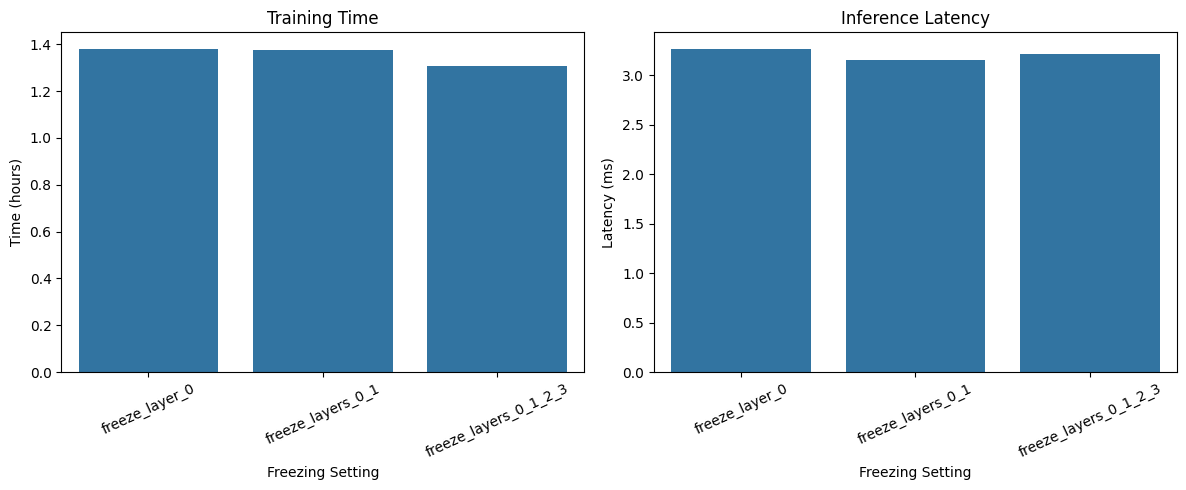

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

config_order = [
    "freeze_layer_0",
    "freeze_layers_0_1",
    "freeze_layers_0_1_2_3"
]

# Training time
sns.barplot(
    data=tinybert_freeze_summary_df,
    x="Config",
    y="Train Time (hrs)",
    order=config_order,
    ax=axes[0]
)

axes[0].set_title("Training Time")
axes[0].set_xlabel("Freezing Setting")
axes[0].set_ylabel("Time (hours)")
axes[0].tick_params(axis="x", rotation=25)

# Inference latency
sns.barplot(
    data=tinybert_freeze_summary_df,
    x="Config",
    y="Inference Latency (ms)",
    order=config_order,
    ax=axes[1]
)

axes[1].set_title("Inference Latency")
axes[1].set_xlabel("Freezing Setting")
axes[1].set_ylabel("Latency (ms)")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig("tinybert_layer_freezing_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()

**2.Plot trainable parameters.**

This plot shows how many parameters are still updated during training for each freezing setting.

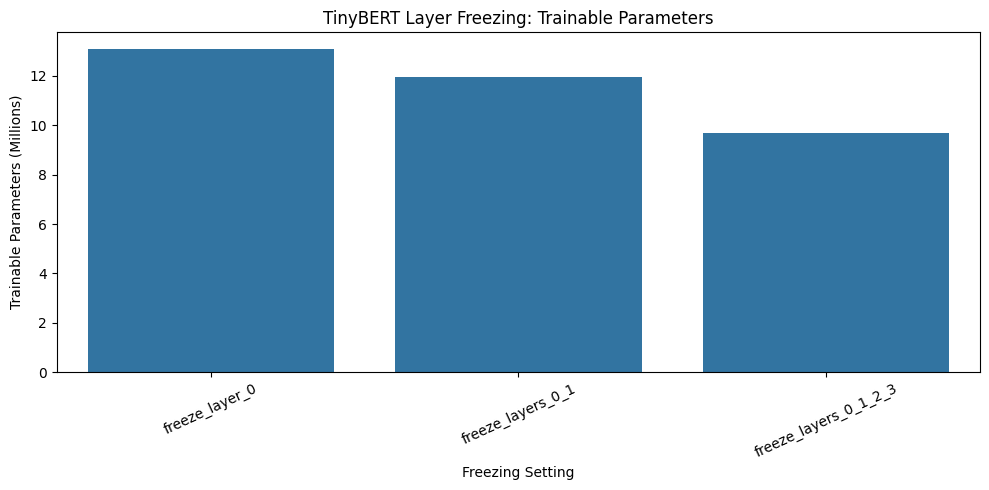

In [ ]:
plt.figure(figsize=(10, 5))

config_order = [
    "freeze_layer_0",
    "freeze_layers_0_1",
    "freeze_layers_0_1_2_3"
]

sns.barplot(
    data=tinybert_freeze_summary_df,
    x="Config",
    y="Trainable Params (M)",
    order=config_order
)

plt.title("TinyBERT Layer Freezing: Trainable Parameters")
plt.xlabel("Freezing Setting")
plt.ylabel("Trainable Parameters (Millions)")
plt.xticks(rotation=25)
plt.tight_layout()

plt.savefig("tinybert_layer_freezing_trainable_params.png", dpi=150, bbox_inches="tight")
plt.show()

**3. Plot F1 against training time.**

This plot shows the trade-off between answer quality and training cost. The better setting should keep F1 high while using less training time.

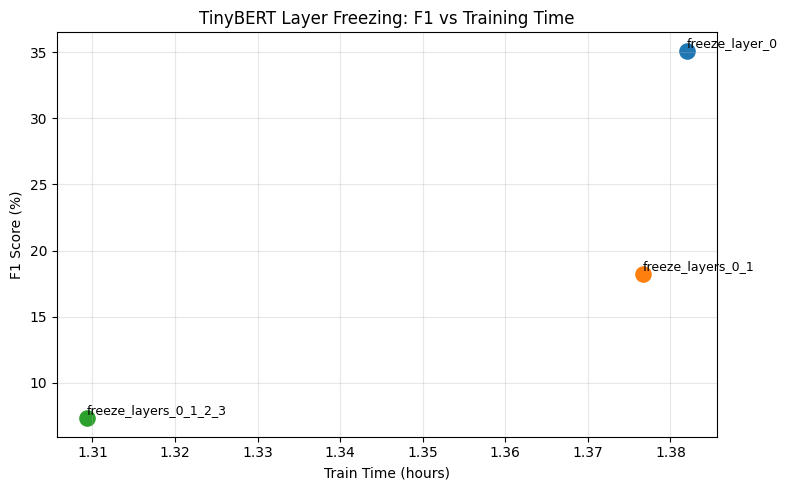

In [ ]:
plt.figure(figsize=(8, 5))

for _, row in tinybert_freeze_summary_df.iterrows():
    plt.scatter(
        row["Train Time (hrs)"],
        row["F1 (%)"],
        s=120
    )

    plt.text(
        row["Train Time (hrs)"],
        row["F1 (%)"],
        row["Config"],
        fontsize=9,
        ha="left",
        va="bottom"
    )

plt.title("TinyBERT Layer Freezing: F1 vs Training Time")
plt.xlabel("Train Time (hours)")
plt.ylabel("F1 Score (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("tinybert_layer_freezing_f1_vs_training_time.png", dpi=150, bbox_inches="tight")
plt.show()

**4.Print the strongest settings from the summary table.**

The code reports the best F1 setting, the fastest setting, and the setting with the fewest trainable parameters.

In [ ]:
best_f1_row = tinybert_freeze_summary_df.sort_values(
    by="F1 (%)",
    ascending=False
).iloc[0]

fastest_row = tinybert_freeze_summary_df.sort_values(
    by="Train Time (hrs)",
    ascending=True
).iloc[0]

fewest_params_row = tinybert_freeze_summary_df.sort_values(
    by="Trainable Params (M)",
    ascending=True
).iloc[0]

print("Best F1 setting:")
print(
    f"{best_f1_row['Config']} | "
    f"F1 = {best_f1_row['F1 (%)']:.2f}% | "
    f"EM = {best_f1_row['EM (%)']:.2f}%"
)

print("\nFastest training setting:")
print(
    f"{fastest_row['Config']} | "
    f"Training Time = {fastest_row['Train Time (hrs)']:.2f} hrs"
)

print("\nFewest trainable parameters:")
print(
    f"{fewest_params_row['Config']} | "
    f"Trainable Params = {fewest_params_row['Trainable Params (M)']:.2f}M"
)

Best F1 setting:
freeze_layer_0 | F1 = 35.12% | EM = 25.00%

Fastest training setting:
freeze_layers_0_1_2_3 | Training Time = 1.31 hrs

Fewest trainable parameters:
freeze_layers_0_1_2_3 | Trainable Params = 9.68M


**5. Plot validation loss.**

This plot checks whether each freezing setting also keeps validation loss under control.

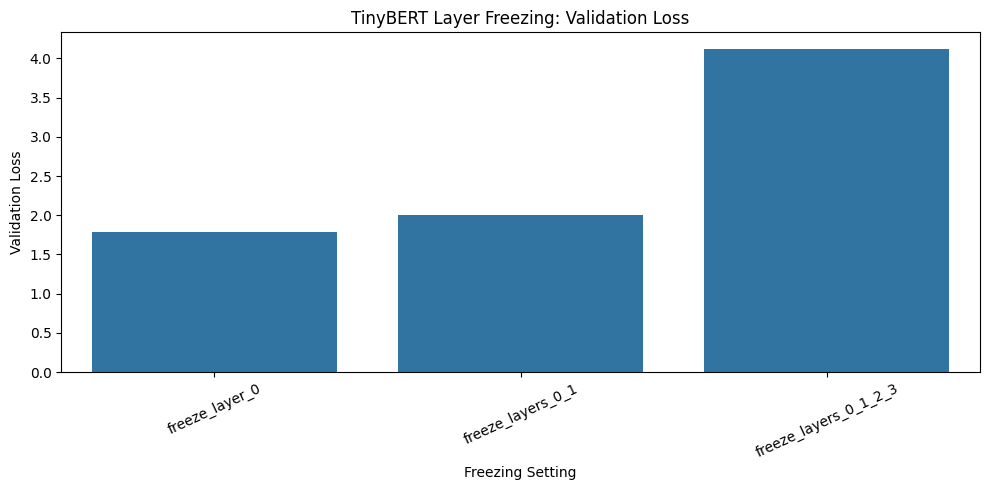

In [ ]:
plt.figure(figsize=(10, 5))

config_order = [
    "freeze_layer_0",
    "freeze_layers_0_1",
    "freeze_layers_0_1_2_3"
]

sns.barplot(
    data=tinybert_freeze_summary_df,
    x="Config",
    y="Validation Loss",
    order=config_order
)

plt.title("TinyBERT Layer Freezing: Validation Loss")
plt.xlabel("Freezing Setting")
plt.ylabel("Validation Loss")
plt.xticks(rotation=25)
plt.tight_layout()

plt.savefig("tinybert_layer_freezing_validation_loss.png", dpi=150, bbox_inches="tight")
plt.show()

## 2)Stratified Data-Size Ablation

After choosing the best freeze setting, I test how it performs with less training data.

The code keeps the selected freeze configuration fixed and trains TinyBERT on stratified subsets of 25%, 50%, and 70% of the training chunks.

This section does not actually train random subsets. The random helper is only used to check that the stratified method selects the same number of chunks.



## Final Comparison

The final table compares:

- full fine-tuning on 100% of the data,
- stratified best-freeze training on 25%,
- stratified best-freeze training on 50%,
- stratified best-freeze training on 70%.

This shows whether the smaller stratified runs can stay close to the full TinyBERT result while using less data and less training time.

1. Prepare article labels for stratified sampling
Each training chunk gets the article title it came from. This lets the subset keep coverage across SQuAD articles.

In [ ]:
# This list will store the article title for each TinyBERT training chunk.
# It must stay in the same order as tb_train_dataset.
tb_train_titles = []

for article in train_articles:
    # SQuAD groups questions under article titles, so this will be our stratification label.
    article_title = article["title"]

    for para in article["paragraphs"]:
        for qa in para["qas"]:
            # Re-tokenize the QA pair only to know how many chunks it created.
            # Some contexts create more than one chunk because of the stride.
            enc = tokenize_tinybert(qa["question"], para["context"])

            # Add the same article title once for every chunk created from this QA pair.
            n_chunks = enc["input_ids"].shape[0]
            tb_train_titles.extend([article_title] * n_chunks)

print(f"Titles collected : {len(tb_train_titles):,}")
print(f"Train chunks     : {len(tb_train_dataset):,}")

# This check makes sure every training chunk has exactly one matching article title.
assert len(tb_train_titles) == len(tb_train_dataset), "Mismatch between titles and train dataset chunks"

Titles collected : 50,527
Train chunks     : 50,527


**2. Create subset index helpers.**

The code defines random and stratified index functions, then checks that both methods select the same number of chunks. The training loop later uses the stratified function.

In [ ]:
from collections import defaultdict
import random

DATA_SIZE_RATIOS = [0.25, 0.50, 0.70]


def get_random_subset_indices(dataset_size, ratio, seed=42):
    # Take a random percentage of the training chunks.
    sample_size = max(1, int(dataset_size * ratio))

    indices = list(range(dataset_size))
    rng = random.Random(seed)
    rng.shuffle(indices)

    return indices[:sample_size]


def get_stratified_subset_indices(titles, ratio, seed=42):
    # Target number of chunks should match random sampling.
    target_size = max(1, int(len(titles) * ratio))

    # Group chunk indices by article title.
    title_to_indices = defaultdict(list)

    for idx, title in enumerate(titles):
        title_to_indices[title].append(idx)

    rng = random.Random(seed)
    selected_indices = []
    leftover_indices = []

    for title, indices in title_to_indices.items():
        shuffled = indices.copy()
        rng.shuffle(shuffled)

        # Take roughly the same percentage from each article.
        group_sample_size = int(len(shuffled) * ratio)

        # Keep at least one chunk from the article when possible.
        if group_sample_size == 0 and len(shuffled) > 0:
            group_sample_size = 1

        selected_indices.extend(shuffled[:group_sample_size])
        leftover_indices.extend(shuffled[group_sample_size:])

    # If stratified selected too many chunks, trim it to the exact target size.
    if len(selected_indices) > target_size:
        rng.shuffle(selected_indices)
        selected_indices = selected_indices[:target_size]

    # If stratified selected too few chunks, fill the rest from leftovers.
    elif len(selected_indices) < target_size:
        rng.shuffle(leftover_indices)
        needed = target_size - len(selected_indices)
        selected_indices.extend(leftover_indices[:needed])

    rng.shuffle(selected_indices)

    return selected_indices


# Quick check to see how many chunks each method selects.
for ratio in DATA_SIZE_RATIOS:
    random_indices = get_random_subset_indices(len(tb_train_dataset), ratio, seed=SEED)
    stratified_indices = get_stratified_subset_indices(tb_train_titles, ratio, seed=SEED)

    print(
        f"{int(ratio * 100):>2}% | "
        f"random: {len(random_indices):,} chunks | "
        f"stratified: {len(stratified_indices):,} chunks"
    )

25% | random: 12,631 chunks | stratified: 12,631 chunks
50% | random: 25,263 chunks | stratified: 25,263 chunks
70% | random: 35,368 chunks | stratified: 35,368 chunks


**3. Select the best freeze configuration.**

The code chooses the best freeze setting from `tinybert_freeze_summary_df`, using F1 first and training time as a tie-breaker.

In [ ]:
config_col = "Config"
f1_col = "F1 (%)"
time_col = "Train Time (hrs)"

# Use the best layer-freezing result
freeze_only_df = tinybert_freeze_summary_df.copy()

if time_col in freeze_only_df.columns:
    freeze_only_df = freeze_only_df.sort_values(
        by=[f1_col, time_col],
        ascending=[False, True]
    )
else:
    freeze_only_df = freeze_only_df.sort_values(
        by=f1_col,
        ascending=False
    )

best_freeze_row = freeze_only_df.iloc[0]

BEST_FREEZE_NAME = best_freeze_row[config_col]
BEST_FREEZE_CONFIG = TINYBERT_FREEZE_CONFIGS[BEST_FREEZE_NAME]

print("Best freeze setting:", BEST_FREEZE_NAME)
print(best_freeze_row)
print("Freeze config:", BEST_FREEZE_CONFIG)

Best freeze setting: freeze_layer_0
Config                    freeze_layer_0
EM (%)                              25.0
F1 (%)                         35.122852
Validation Loss                 1.787482
Trainable Params (M)           13.111034
Frozen Params (M)               1.142184
Train Time (hrs)                1.382009
Inference Latency (ms)          3.272295
Name: 0, dtype: object
Freeze config: {'freeze_layers': [0]}


**4. Train stratified subsets with the best freeze setting.**

For each data size, the loop selects a stratified subset, applies `BEST_FREEZE_CONFIG`, trains TinyBERT, evaluates EM/F1 and validation loss, then saves the results.

In [ ]:
import json
from pathlib import Path
from transformers.trainer_utils import get_last_checkpoint

stratified_best_freeze_results = {}

DATA_SIZE_EPOCHS = NUM_EPOCHS
DATA_ABLATION_EVAL_LIMIT = 200

data_ablation_eval_examples = val_examples[:DATA_ABLATION_EVAL_LIMIT]

DATA_ABLATION_ROOT = Path("./tinybert_stratified_best_freeze_runs")
DATA_ABLATION_ROOT.mkdir(exist_ok=True)

for ratio in DATA_SIZE_RATIOS:
    data_size_percent = int(ratio * 100)

    print(f"\n{'=' * 60}")
    print(f"Stratified data size: {data_size_percent}%")
    print(f"{'=' * 60}")

    run_name = f"stratified_{data_size_percent}"
    run_dir = DATA_ABLATION_ROOT / run_name
    metrics_path = run_dir / "metrics.json"
    final_model_dir = run_dir / "final_model"

    run_dir.mkdir(parents=True, exist_ok=True)

    # Skip finished runs
    if metrics_path.exists():
        print(f"Saved metrics found for {run_name}. Skipping training.")

        with open(metrics_path, "r", encoding="utf-8") as f:
            stratified_best_freeze_results[data_size_percent] = json.load(f)

        print(stratified_best_freeze_results[data_size_percent])
        continue

    subset_indices = get_stratified_subset_indices(
        titles=tb_train_titles,
        ratio=ratio,
        seed=SEED
    )

    train_subset = tb_train_dataset.select(subset_indices)

    # Start from the same TinyBERT checkpoint
    sampling_model = AutoModelForQuestionAnswering.from_pretrained(
        TINYBERT_CHECKPOINT
    ).to(DEVICE)

    apply_tinybert_freeze(
        sampling_model,
        freeze_layers=BEST_FREEZE_CONFIG["freeze_layers"]
    )

    total, trainable, frozen = count_tinybert_trainable(sampling_model)

    print(f"Training chunks      : {len(train_subset):,}")
    print(f"Trainable parameters : {trainable / 1e6:.2f}M")
    print(f"Frozen parameters    : {frozen / 1e6:.2f}M")

    sampling_args = TrainingArguments(
        output_dir=str(run_dir),
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM_STEPS,
        num_train_epochs=DATA_SIZE_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        seed=SEED,
        logging_steps=50,
        report_to="none",
        fp16=torch.cuda.is_available(),
    )

    sampling_trainer = Trainer(
        model=sampling_model,
        args=sampling_args,
        train_dataset=train_subset,
        eval_dataset=tb_val_dataset,
        data_collator=default_data_collator,
    )

    last_checkpoint = get_last_checkpoint(str(run_dir))

    train_start = time.time()
    sampling_trainer.train(resume_from_checkpoint=last_checkpoint)
    train_time_hrs = (time.time() - train_start) / 3600

    eval_results = sampling_trainer.evaluate()
    val_loss = eval_results["eval_loss"]

    sampling_pipeline = pipeline(
        "question-answering",
        model=sampling_model,
        tokenizer=tinybert_tokenizer,
        device=0 if torch.cuda.is_available() else -1
    )

    em_scores = []
    f1_scores = []

    for ex in data_ablation_eval_examples:
        output = sampling_pipeline(
            question=ex["question"],
            context=ex["context"],
            max_answer_len=40
        )

        em, f1 = score_prediction(ex["gold_answers"], output["answer"])
        em_scores.append(em)
        f1_scores.append(f1)

    sampling_em = np.mean(em_scores) * 100
    sampling_f1 = np.mean(f1_scores) * 100

    stratified_best_freeze_results[data_size_percent] = {
        "config": f"stratified_{data_size_percent}_best_freeze",
        "data_size_percent": data_size_percent,
        "training_type": "Stratified + Best Freeze",
        "freeze_config": BEST_FREEZE_NAME,
        "train_chunks": len(train_subset),
        "em": float(sampling_em),
        "f1": float(sampling_f1),
        "val_loss": float(val_loss),
        "train_time_hrs": float(train_time_hrs),
        "trainable_params": int(trainable),
        "frozen_params": int(frozen),
    }

    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(stratified_best_freeze_results[data_size_percent], f, indent=2)

    sampling_model.save_pretrained(str(final_model_dir))
    tinybert_tokenizer.save_pretrained(str(final_model_dir))

    del sampling_pipeline
    del sampling_model
    del sampling_trainer

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nStratified best-freeze data-size ablation finished.")


Stratified data size: 25%


Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at huawei-noah/TinyBERT_General_4L_312D and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training chunks      : 12,631
Trainable parameters : 13.11M
Frozen parameters    : 1.14M


Epoch,Training Loss,Validation Loss
0,5.040000,4.711720
1,4.290800,4.113519
2,4.081200,3.905710
4,3.536500,3.418810
5,3.417800,3.278795
6,3.229700,3.106527
8,3.013800,2.960657
9,3.032900,2.882034
10,2.863700,2.826916
12,2.686500,2.727961



Stratified data size: 50%


...

Epoch,Training Loss,Validation Loss
0,4.574700,4.400834
2,3.606400,3.365827
4,3.037100,2.737527
6,2.542100,2.328550
8,2.355200,2.174136
10,2.138900,2.123401
12,2.141100,2.068094
14,2.080800,2.046354
16,2.051500,2.033313
18,2.034200,2.031752


Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at huawei-noah/TinyBERT_General_4L_312D and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Stratified data size: 70%
Training chunks      : 35,368
Trainable parameters : 13.11M
Frozen parameters    : 1.14M


Epoch,Training Loss,Validation Loss
0,4.366300,4.236392
1,3.885400,3.695286
2,3.334800,3.019815
4,2.600700,2.313359
5,2.386500,2.164227
6,2.290500,2.092897
8,2.137100,1.995596
9,2.160800,1.962273
10,2.031900,1.949628
12,1.964000,1.921654



Stratified best-freeze data-size ablation finished.


**5. Build the full-vs-stratified comparison table.**

The next code cell evaluates the full fine-tuned TinyBERT model, adds the stratified best-freeze runs, and saves the combined table as `tinybert_full_vs_stratified_best_freeze.csv`.

In [ ]:
# Evaluate the saved full fine-tuned TinyBERT model
full_model = AutoModelForQuestionAnswering.from_pretrained(
    TINYBERT_SAVE_PATH
).to(DEVICE)

full_total, full_trainable, full_frozen = count_tinybert_trainable(full_model)

full_eval_args = TrainingArguments(
    output_dir="./tinybert_full_finetune_eval",
    per_device_eval_batch_size=BATCH_SIZE,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

full_eval_trainer = Trainer(
    model=full_model,
    args=full_eval_args,
    eval_dataset=tb_val_dataset,
    data_collator=default_data_collator,
)

full_eval_results = full_eval_trainer.evaluate()
full_val_loss = full_eval_results["eval_loss"]

full_pipeline = pipeline(
    "question-answering",
    model=full_model,
    tokenizer=tinybert_tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

em_scores = []
f1_scores = []

for ex in data_ablation_eval_examples:
    output = full_pipeline(
        question=ex["question"],
        context=ex["context"],
        max_answer_len=40
    )

    em, f1 = score_prediction(ex["gold_answers"], output["answer"])
    em_scores.append(em)
    f1_scores.append(f1)

full_em = np.mean(em_scores) * 100
full_f1 = np.mean(f1_scores) * 100

full_train_time = globals().get("wall_clock_hrs", np.nan)

comparison_rows = [{
    "Config": "full_finetune_100",
    "Training Type": "Full Fine-Tuning",
    "Data Size (%)": 100,
    "Freeze Config": "none",
    "Train Chunks": len(tb_train_dataset),
    "EM (%)": float(full_em),
    "F1 (%)": float(full_f1),
    "Validation Loss": float(full_val_loss),
    "Train Time (hrs)": float(full_train_time),
    "Trainable Params (M)": full_trainable / 1e6,
    "Frozen Params (M)": full_frozen / 1e6,
}]

for _, metrics in stratified_best_freeze_results.items():
    comparison_rows.append({
        "Config": metrics["config"],
        "Training Type": metrics["training_type"],
        "Data Size (%)": metrics["data_size_percent"],
        "Freeze Config": metrics["freeze_config"],
        "Train Chunks": metrics["train_chunks"],
        "EM (%)": metrics["em"],
        "F1 (%)": metrics["f1"],
        "Validation Loss": metrics["val_loss"],
        "Train Time (hrs)": metrics["train_time_hrs"],
        "Trainable Params (M)": metrics["trainable_params"] / 1e6,
        "Frozen Params (M)": metrics["frozen_params"] / 1e6,
    })

tinybert_full_vs_stratified_freeze_df = pd.DataFrame(comparison_rows)

tinybert_full_vs_stratified_freeze_df = tinybert_full_vs_stratified_freeze_df.sort_values(
    by="Data Size (%)",
    ascending=False
)

tinybert_full_vs_stratified_freeze_df.to_csv(
    "tinybert_full_vs_stratified_best_freeze.csv",
    index=False
)

del full_pipeline
del full_model
del full_eval_trainer

if torch.cuda.is_available():
    torch.cuda.empty_cache()

tinybert_full_vs_stratified_freeze_df

Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at huawei-noah/TinyBERT_General_4L_312D and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


,Config,Training Type,Data Size (%),Freeze Config,Train Chunks,EM (%),F1 (%),Validation Loss,Train Time (hrs),Trainable Params (M),Frozen Params (M)
0,full_finetune_100,Full Fine-Tuning,100,none,50527,0.0,6.312257,5.964944,1.431130,14.253218,0.000000
3,stratified_70_best_freeze,Stratified + Best Freeze,70,freeze_layer_0,35368,24.0,34.413929,1.890080,0.996779,13.111034,1.142184
2,stratified_50_best_freeze,Stratified + Best Freeze,50,freeze_layer_0,25263,23.5,33.056453,2.030442,0.740736,13.111034,1.142184
1,stratified_25_best_freeze,Stratified + Best Freeze,25,freeze_layer_0,12631,18.0,26.517763,2.545325,0.418702,13.111034,1.142184


**6. Plot full fine-tuning against stratified best-freeze runs.**

The plot compares EM and F1 for 25%, 50%, and 70% stratified best-freeze training against the full 100% TinyBERT result.

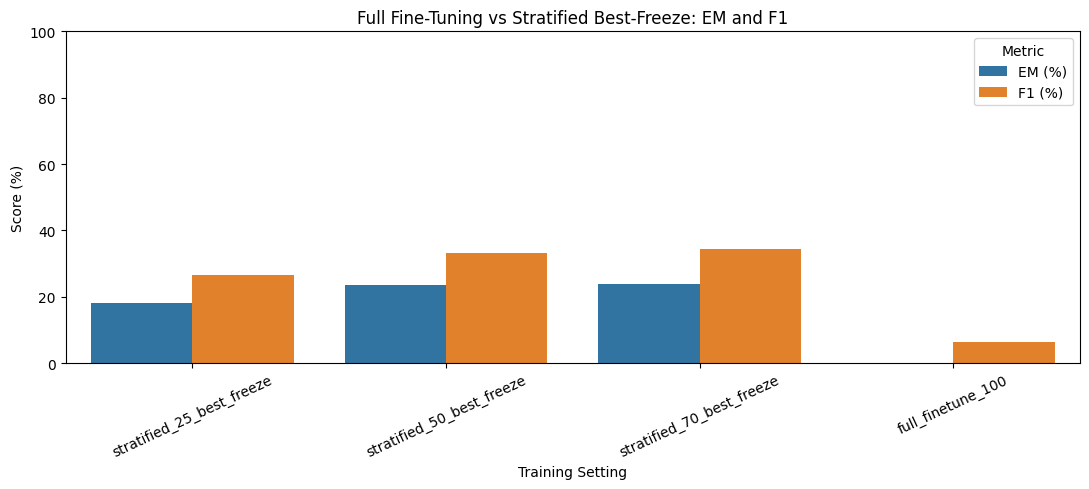

In [ ]:


quality_plot_df = tinybert_full_vs_stratified_freeze_df.melt(
    id_vars=["Config", "Training Type", "Data Size (%)"],
    value_vars=["EM (%)", "F1 (%)"],
    var_name="Metric",
    value_name="Score"
)

config_order = [
    "stratified_25_best_freeze",
    "stratified_50_best_freeze",
    "stratified_70_best_freeze",
    "full_finetune_100"
]

plt.figure(figsize=(11, 5))

sns.barplot(
    data=quality_plot_df,
    x="Config",
    y="Score",
    hue="Metric",
    order=config_order
)

plt.title("Full Fine-Tuning vs Stratified Best-Freeze: EM and F1")
plt.xlabel("Training Setting")
plt.ylabel("Score (%)")
plt.xticks(rotation=25)
plt.ylim(0, 100)
plt.tight_layout()

plt.savefig("tinybert_full_vs_stratified_best_freeze_em_f1.png", dpi=150, bbox_inches="tight")
plt.show()



### 🔷 <font color="#9CE2FF">Salma's Work Ends Here</font>|